# ZShooter Science Validation

This notebook is the release-facing validation path for the ZShooter ScopeSim model. It is meant to answer science and instrument-engineering questions directly: what is configured, what physical effects are included, what the dominant rates are, whether simple back-of-the-envelope scales agree, and what changes when common background/AO/source knobs are toggled.

The older `zshooter_validation.ipynb` remains useful as a developer lab notebook. This notebook intentionally keeps the important knobs close to the calculations they control, and it leaves the code visible so a scientist can rerun the same reasoning with different source, slit, seeing, airmass, or background settings.

In [1]:
%matplotlib inline
from collections import OrderedDict
from contextlib import contextmanager
import logging
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.table import Table

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp


In [2]:
from zs_scopesim_tools.helpers import configure_path_and_logging, disable_scopesim_progress_bars, disable_scopesim_top_level_catch, validation_work_dir, warning_prevent_sync_alt_ra_dec, zshooter_package_dir, ignore_warnings
from zs_scopesim_tools.sources import angle_from_cmds, constant_photon_flux_flat, field_angle_demo_sources, lamp_flat
from zs_scopesim_tools.plots import plot_detector_background_budget, plot_detector_image_grid, plot_emissivity_sanity, plot_post_disperser_diffuse_background, plot_readout_cross_dispersion_cut, plot_readout_delta_overview, plot_readout_overview, plot_slit_adc_psf_scenes, plot_slit_loss_by_arm, plot_slit_width_loss, plot_source, plot_trace_resolving_power_detector_maps, plot_transmission_sanity
from zs_scopesim_tools.validation import build_emissivity_sanity_data, build_post_disperser_diffuse_background_data, build_slit_adc_psf_scene_data, build_slit_loss_data, build_slit_width_loss_data, build_transmission_sanity_data, detector_background_budget_table, detector_geometry_table, detector_qe_accounting_table, detector_selector_matrix, effect_name, fetch_effect_spectrum_or_transmission, fov_image_plane_counts, get_effect, post_disperser_diffuse_effect_consistency_table, readout_delta_summary_table, resolution_element_snr_summary_table, science_truth_crosscheck_table, slit_adc_psf_status_table, slit_pair_status_table, source_photon_crosscheck_table, source_position_table, trace_catalog_table, trace_resolution_diagnostic_table, trace_resolution_summary_display_table, trace_resolution_summary_table, validate_emissivity_sanity_data, validate_post_disperser_diffuse_background_data, validate_post_disperser_diffuse_effect_consistency, validate_transmission_sanity_data
ignore_warnings()

## Run Configuration

Edit this cell first. The notebook is organized so the configuration, source construction, and background toggles are near the calculations that depend on them. The altitude is derived from the requested airmass and RA/Dec are cleared so sky and PSF terms are driven by the quantities that matter for this simulator validation: airmass, seeing, sky brightness, slit, exposure time, and enabled effects.

In [3]:
irdb_path = configure_path_and_logging(irdb_path="/Users/jibailey/src/irdb", level="warning")
zshooter_dir = zshooter_package_dir(irdb_path)
output_dir = validation_work_dir(irdb_path, name="science_validation_outputs")
hide_scopesim_progress = True
disable_scopesim_top_level_catch()

from skycalc_ipy.core import SkyModel, get_cache_dir
SkyModel.REQUEST_TIMEOUT = 60
print(f"SkyCalc timeout: {SkyModel.REQUEST_TIMEOUT}s; cache: {get_cache_dir()}")

cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
validation_brightness = "grey"
cmd["!OBS.airmass"] = 1.1
cmd["!OBS.seeing"] = 0.65
cmd["!OBS.brightness"] = validation_brightness
cmd["!OBS.pupil_angle"] = 0.0
cmd["!OBS.dit"] = 3600
# cmd["!OBS.dit_green"] = 150
cmd["!OBS.ndit"] = 2
cmd["!INST.vis_curr_slit"] = 0.33
cmd["!INST.nir_curr_slit"] = 0.33
# ZShooter_v2 currently keeps spectral resolution as this explicit scalar; update it with the slit if testing a slit-dependent resolution assumption.
cmd["!SIM.spectral.spectral_resolution"] = 40000
cmd["!INST.include_diffuse_emmisivity"] = False
warning_prevent_sync_alt_ra_dec(cmd)

component_metadata = {
    "telescope_reflection": {"throughput_group": "telescope", "emission_phase": "pre_disperser"},
    "ir_blocking_filter_selector": {"throughput_group": "ir_blocking_filter"},
}

zs = sim.OpticalTrain(cmd)
print(f"Validation outputs: {output_dir}")

SkyCalc timeout: 60s; cache: /Users/jibailey/.astar/skycalc_ipy
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: wmin 299.99999999999994 is below the minimum wavelength covered by SkyCalc. Setting to 300 nm.
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.effects.sky_ter_curves - WARNING: Local time is outside of the range covered by the PALACE model (18-6h). Defaulting to tbin=0 (all times).
astar.scopesim.utils - WARNING: Obstime is not after sunset!
astar.scopesim.utils - WARNING: Obstime is not after sunset!
py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:165: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  fov = thetrace.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed i

In [4]:
def cmd_value(key):
    try:
        return from_currsys(key, cmd)
    except Exception:
        return None


def display_frame(data, *, columns=None, rename=None, formats=None):
    if isinstance(data, Table):
        view = data[columns] if columns is not None else data
        frame = view.to_pandas()
    else:
        frame = pd.DataFrame(data)
        if columns is not None:
            frame = frame.loc[:, columns]
    if rename:
        frame = frame.rename(columns=rename)
    styler = frame.style.hide(axis="index")
    if formats:
        active_formats = {key: value for key, value in formats.items() if key in frame.columns}
        styler = styler.format(active_formats, na_rep="--")
    display(styler)


def compact_range(minimum, maximum, digits=1):
    if not np.isfinite(minimum) or not np.isfinite(maximum):
        return "--"
    if np.isclose(minimum, maximum, rtol=1e-4, atol=10**-digits):
        return f"{minimum:.{digits}f}"
    return f"{minimum:.{digits}f}-{maximum:.{digits}f}"

run_card = Table(rows=[
    {"quantity": "instrument", "value": "ZShooter_v2 SPEC", "why_it_matters": "loads the release IRDB model"},
    {"quantity": "airmass", "value": cmd_value("!OBS.airmass"), "why_it_matters": "sets atmospheric path, dispersion, and sky"},
    {"quantity": "altitude [deg]", "value": cmd_value("!OBS.alt"), "why_it_matters": "derived from airmass for ScopeSim AltAz context"},
    {"quantity": "RA/Dec", "value": f"{cmd_value('!OBS.ra')}/{cmd_value('!OBS.dec')}", "why_it_matters": "cleared so they do not override airmass"},
    {"quantity": "seeing [arcsec]", "value": cmd_value("!OBS.seeing"), "why_it_matters": "natural-seeing PSF scale"},
    {"quantity": "sky brightness", "value": cmd_value("!OBS.brightness"), "why_it_matters": "SkyCalc continuum/line brightness preset"},
    {"quantity": "VIS slit [arcsec]", "value": cmd_value("!INST.vis_curr_slit"), "why_it_matters": "source throughput and resolution"},
    {"quantity": "NIR slit [arcsec]", "value": cmd_value("!INST.nir_curr_slit"), "why_it_matters": "source throughput and resolution"},
    {"quantity": "spectral resolving power guardrail", "value": cmd_value("!SIM.spectral.spectral_resolution"), "why_it_matters": "internal spectral work grid / sky sampling guardrail"},
    {"quantity": "DIT / green DIT / NDIT", "value": f"{cmd_value('!OBS.dit')} / {cmd_value('!OBS.dit_green')} / {cmd_value('!OBS.ndit')}", "why_it_matters": "detector background and noise scaling"},
    {"quantity": "pupil angle [deg]", "value": cmd_value("!OBS.pupil_angle"), "why_it_matters": "source-pair orientation used below"},
])
display_frame(run_card, rename={"why_it_matters": "why it matters"})

print("Trace catalog")
trace_catalog = trace_catalog_table(get_effect(zs, "trace_list_analytical"))
display_frame(
    trace_catalog,
    columns=["trace_id", "aperture_id", "image_plane_id", "wave_min_um", "wave_max_um"],
    rename={
        "trace_id": "trace",
        "aperture_id": "aperture id",
        "image_plane_id": "image plane id",
        "wave_min_um": "wave min [um]",
        "wave_max_um": "wave max [um]",
    },
    formats={"wave min [um]": "{:.4f}", "wave max [um]": "{:.4f}"},
)
print("FoV image-plane counts")
display_frame(
    fov_image_plane_counts(zs),
    rename={"image_plane_id": "image plane id", "n_fovs": "FoVs"},
)


quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
airmass,1.1,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.38002267134289,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.65,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
VIS slit [arcsec],0.33,source throughput and resolution
NIR slit [arcsec],0.33,source throughput and resolution
spectral resolving power guardrail,40000,internal spectral work grid / sky sampling guardrail
DIT / green DIT / NDIT,3600 / 300.0 / 2,detector background and noise scaling


Trace catalog


trace,aperture id,image plane id,wave min [um],wave max [um]
b_100,0,0,0.3586,0.3697
b_101,0,0,0.3552,0.3661
b_102,0,0,0.3518,0.3626
b_103,0,0,0.3485,0.3592
b_104,0,0,0.3453,0.3558
b_105,0,0,0.3421,0.3525
b_106,0,0,0.3390,0.3493
b_107,0,0,0.3359,0.3461
b_108,0,0,0.3329,0.3430
b_109,0,0,0.3300,0.3399


FoV image-plane counts


image plane id,FoVs
0,35
1,31
2,21
3,24
4,12
5,7


## Trace Geometry And Resolution Scale

This detector-facing diagnostic samples the loaded spectral traces on the active image planes. The table gives compact channel ranges; the first map shows local resolving power from the trace geometry and detector pixel scale, while the second map shows the corresponding spectral-element sampling width. Blank pixels are off trace. The plotted samples are kept only where the sampled slit footprint is fully on detector; the trace catalog below is the check for the total loaded order count. Detector rotation is part of the trace geometry being checked; `detector_pad` is legacy metadata and is not applied to the optical trace geometry.

,ch,id,orders,wave nm,disp nm/pix,R k,nyq R k,pix/resel,seeing
0,B,0,35,306-438,0.0037-0.0078,12.3-19.2,27.3-42.7,16.7-24.6,"0.73""/4.7 pix"
1,G,1,31,424-657,0.0052-0.0118,12.3-18.8,27.5-42.0,15.8-22.5,"0.68""/4.4 pix"
2,R,2,21,643-1022,0.0079-0.0180,12.4-18.8,27.6-42.0,14.6-20.9,"0.63""/4.0 pix"
3,YJ,3,23,947-1349,0.0122-0.0232,12.6-18.1,28.2-40.3,13.6-19.6,"0.59""/3.8 pix"
4,H,4,11,1468-1874,0.0190-0.0323,12.6-18.2,28.1-40.7,12.7-17.8,"0.54""/3.5 pix"
5,K,5,7,2022-2479,0.0256-0.0427,12.6-18.2,28.1-40.6,12.0-16.8,"0.51""/3.3 pix"


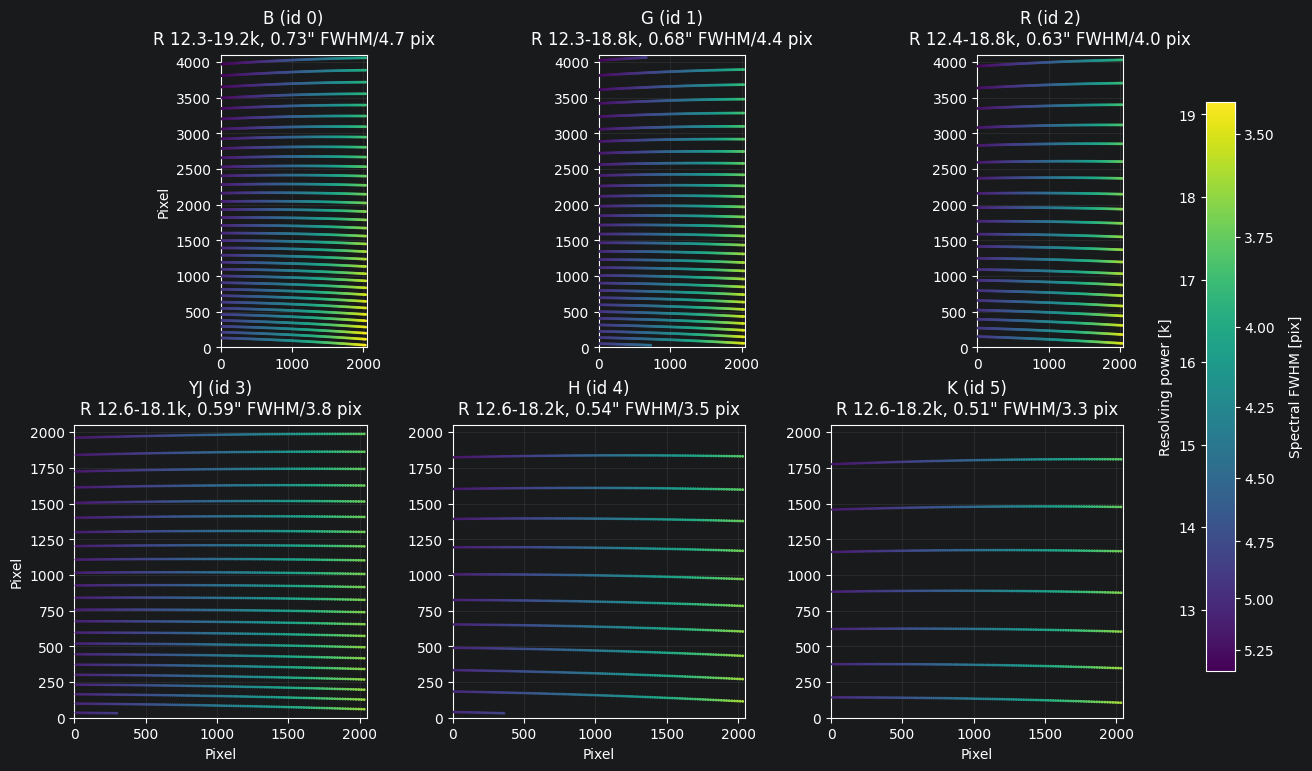

In [5]:
trace_resolution = trace_resolution_diagnostic_table(zs, samples_per_trace=128)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
display(trace_resolution_summary_display_table(trace_resolution_summary))

fig, axes = plot_trace_resolving_power_detector_maps(trace_resolution)
display(fig)
plt.close(fig)


## Model Inventory

This is the compact checklist of what is active in the simulator. A release validation notebook should make omissions as visible as included machinery. Total integrated scatter from bright sky lines is not yet a ScopeSim/IRDB effect; the relevant physics is shown later as a back-of-the-envelope scale and should become a follow-up ScopeSim effect.

In [6]:
inventory_rows = []
for effect in zs.optics_manager.all_effects:
    meta = getattr(effect, "meta", {}) or {}
    inventory_rows.append({
        "included": bool(getattr(effect, "include", True)),
        "effect": effect_name(effect),
        "class": effect.__class__.__name__,
        "selector": meta.get("selector_key", ""),
        "source file": meta.get("filename", ""),
    })
inventory = pd.DataFrame(inventory_rows)
display_frame(inventory[inventory["included"]])

known_omissions = pd.DataFrame([
    {"item": "Total integrated scatter (TIS)", "status": "not yet a ScopeSim effect", "consequence": "bright sky-line scatter/interline floor must be handled as a BoE note until implemented"},
    {"item": "Extracted-spectrum optimal aperture", "status": "not a detector readout product", "consequence": "readout/SNR images are per-pixel diagnostics, not a reduced spectrum"},
    {"item": "Science-specific observing sequence", "status": "user notebook layer", "consequence": "change DIT/NDIT/slit/source here before rerunning"},
])
display_frame(known_omissions)


included,effect,class,selector,source file
True,atmo_transmission,TERCurve,,TER_maunakea_tapas.dat
True,continuum_emission,SkyBackgroundTERCurve,,nan
True,airglow_and_interline_continuum,PalaceAirglowEmission,,nan
True,seeing_psf,AOEnhanceablePSF,,nan
True,adc_residuals,ADCShift,,adc_residuals.dat
True,telescope_reflection,SurfaceList,,LIST_keck_mirrors.dat
True,dichroic_tree,DichroicTree,,nan
True,slitwheel_selector,SelectorWheel,aperture_id,nan
True,channel_optics_selector,SelectorWheel,aperture_id,nan
True,trace_eff_analytical,EchelleSpectralEfficiency,,traces/echelle_trace_parameters.dat


item,status,consequence
Total integrated scatter (TIS),not yet a ScopeSim effect,bright sky-line scatter/interline floor must be handled as a BoE note until implemented
Extracted-spectrum optimal aperture,not a detector readout product,"readout/SNR images are per-pixel diagnostics, not a reduced spectrum"
Science-specific observing sequence,user notebook layer,change DIT/NDIT/slit/source here before rerunning


## Slit Loss, Seeing, AO Design Curves, And Atmospheric Dispersion

These plots are diagnostics for the optical geometry rather than extracted data products. The first plot includes the current-airmass ADC-residual curve used by the throughput plot below; the other curves remain as zenith and 60-degree elevation reference cases. The second plot isolates PSF loss as a function of slit width. Legend labels pair VIS/NIR wavelengths by construction, for example `0.65" NS, 500/1250 nm`; if that pairing breaks, the plot should fail instead of silently changing meaning.


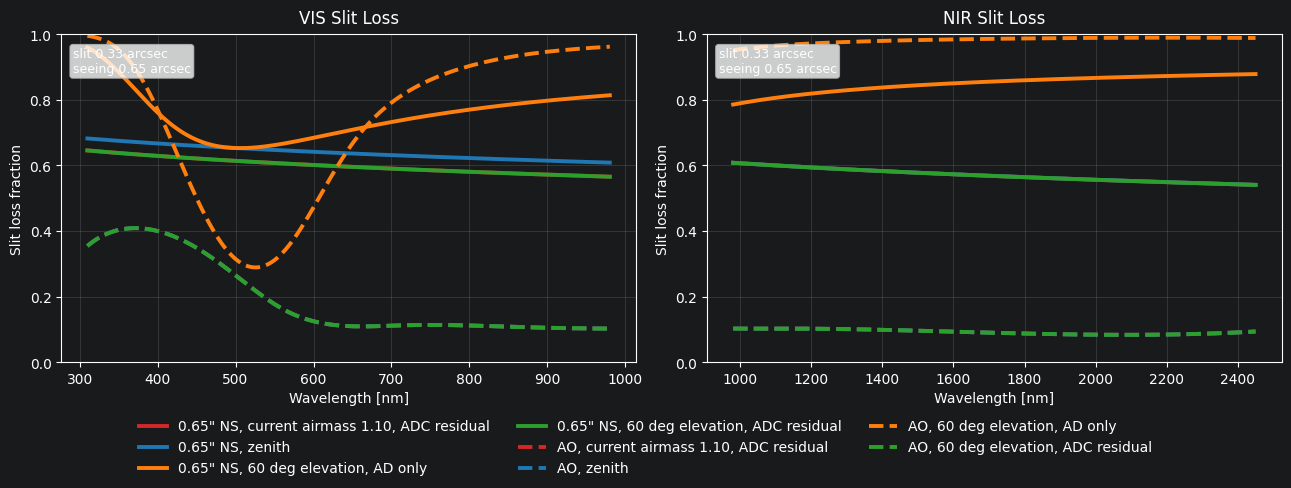

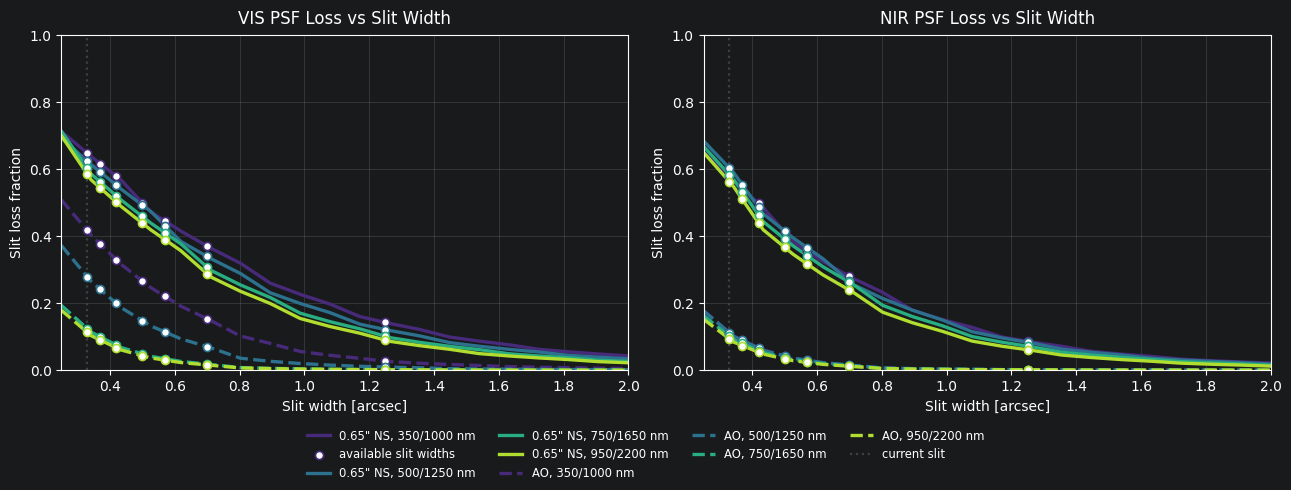

In [7]:
slit_loss_data = build_slit_loss_data(zs, n_wave=160, slit_length=10*u.arcsec, grid_step=0.04*u.arcsec)
fig, axes = plot_slit_loss_by_arm(slit_loss_data)

slit_width_loss_data = build_slit_width_loss_data(zs, slit_length=10*u.arcsec, grid_step=0.04*u.arcsec)
fig, axes = plot_slit_width_loss(slit_width_loss_data)


In [8]:
slit_width_rows = []
for arm_name, arm in slit_width_loss_data["arms"].items():
    slit_widths = arm["slit_widths_arcsec"].to_value(u.arcsec)
    current_slit = arm["current_slit_width_arcsec"].to_value(u.arcsec)
    for curve in arm["curves"].values():
        slit_width_rows.append({
            "arm": arm_name,
            "PSF / ADC case": curve["psf_mode"],
            "wavelength [nm]": curve["wavelength_nm"],
            "active slit [arcsec]": current_slit,
            "transmission at active slit": np.interp(current_slit, slit_widths, curve["throughput"]),
            "loss at active slit": np.interp(current_slit, slit_widths, curve["loss"]),
        })
display_frame(
    slit_width_rows,
    formats={
        "wavelength [nm]": "{:.0f}",
        "active slit [arcsec]": "{:.2f}",
        "transmission at active slit": "{:.3f}",
        "loss at active slit": "{:.3f}",
    },
)

display_frame(slit_adc_psf_status_table(zs))


arm,PSF / ADC case,wavelength [nm],active slit [arcsec],transmission at active slit,loss at active slit
VIS,no_ao,350,0.33,0.352,0.648
VIS,no_ao,500,0.33,0.376,0.624
VIS,no_ao,750,0.33,0.398,0.602
VIS,no_ao,950,0.33,0.415,0.585
VIS,ao,350,0.33,0.583,0.417
VIS,ao,500,0.33,0.721,0.279
VIS,ao,750,0.33,0.876,0.124
VIS,ao,950,0.33,0.887,0.113
NIR,no_ao,1000,0.33,0.425,0.575
NIR,no_ao,1250,0.33,0.397,0.603


category,scope,name,class,setting,note
slit,"aperture_id 0, 1, 2, 3, 4, 5",slitwheel_selector,SlitWheel,current_slit=0.33,filename_format=slits/slit_{:.2f}_as.dat
adc optics,"aperture_id 0, 1, 2",channel_optics_selector,SurfaceList,"VIS_ADC_12, VIS_ADC_34",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
adc optics,"aperture_id 3, 4, 5",channel_optics_selector,SurfaceList,"NIR_ADC_1, NIR_ADC_2, NIR_ADC_3, NIR_ADC_4",ADC is represented here as optical surfaces; this row is not an atmospheric-dispersion correction toggle.
atmospheric dispersion,global,adc_residuals,ADCShift,filename=adc_residuals.dat,
psf,global,seeing_psf,AOEnhanceablePSF,"filename=None, fwhm={'seeing': 0.65, 'seeing_unit': 'arcsec', 'pivot_wave': 500, 'pivot_wave_unit': 'nm'}, alpha=4.765",


## Throughput Components And Total

This figure has two jobs. The six small panels preserve the diagnostic decomposition: telescope/static optics, selected instrument optics, dichroics, disperser/order efficiencies, trace-position detector QE, and the resulting instrument/order curves. The all-channel panel underneath is the presentation summary: thin background curves show telescope, dichroic, optics, active slit transmission, and trace-QE median; dashed curves are `instrument` and solid curves are `total` after telescope and active slit transmission.


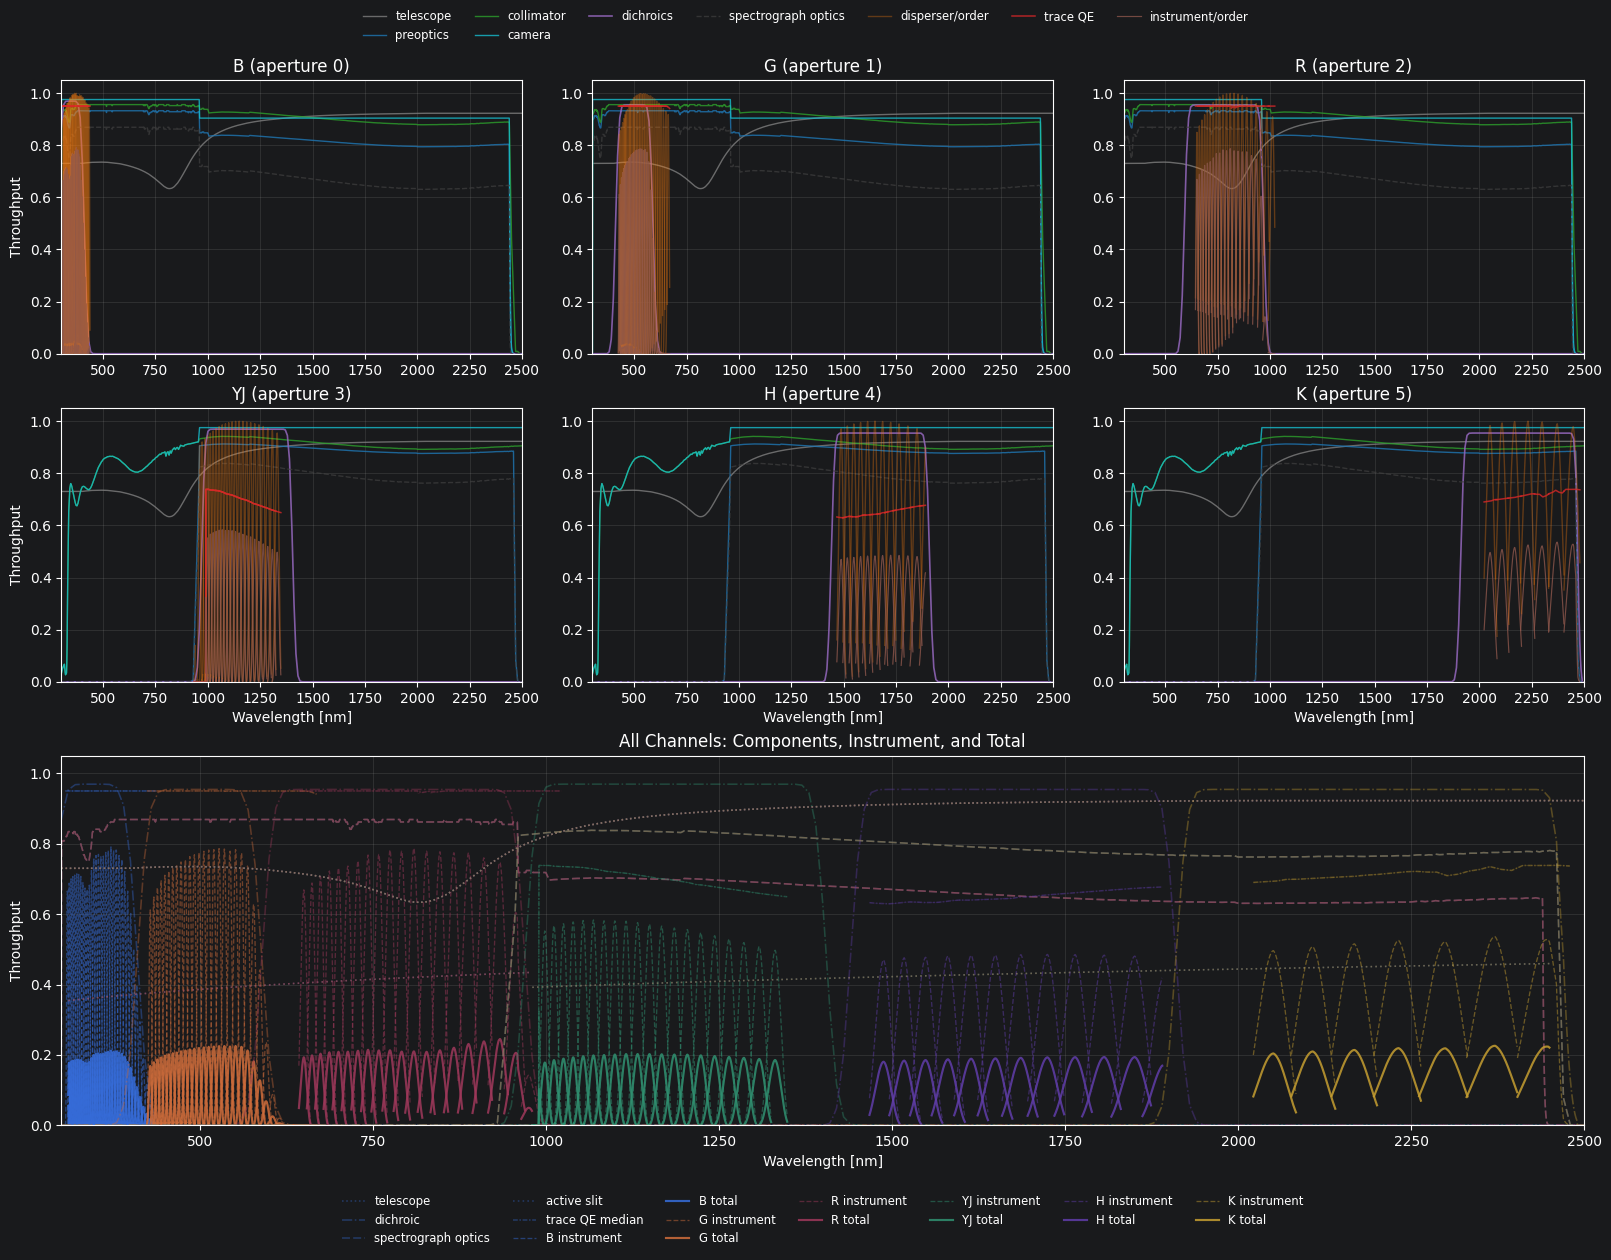

In [9]:
sim_wave_min_nm = u.Quantity(cmd_value("!SIM.spectral.wave_min"), u.um).to_value(u.nm)
sim_wave_max_nm = u.Quantity(cmd_value("!SIM.spectral.wave_max"), u.um).to_value(u.nm)
wave_nm = np.linspace(sim_wave_min_nm, sim_wave_max_nm, 5000) * u.nm
transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_transmission_sanity_data(transmission_data)
fig, axes = plot_transmission_sanity(transmission_data, slit_loss_data=slit_loss_data, summary_component_alpha=0.38, summary_component_linewidth=1.15)


In [10]:
def active_slit_transmission_for_channel(channel_label):
    arm_name = "VIS" if channel_label in ("B", "G", "R") else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(wave_values, arm["wave_nm"].to_value(u.nm), curve["throughput"], left=np.nan, right=np.nan)

throughput_rows = []
wave_values = transmission_data["wave_nm"].to_value(u.nm)
for aperture_id, channel in transmission_data["channels"].items():
    active_slit = active_slit_transmission_for_channel(channel["label"])
    order_peaks = []
    for trace_id, order in channel["orders"].items():
        total = np.asarray(order["total_with_telescope_no_slit"], dtype=float) * active_slit
        finite = np.isfinite(total)
        if not np.any(finite):
            continue
        peak_index = np.nanargmax(total)
        order_peaks.append((trace_id, wave_values[peak_index], total[peak_index]))
    best_trace, best_wave, best_throughput = max(order_peaks, key=lambda item: item[2])
    throughput_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "best_order": best_trace,
        "best_wave_nm": best_wave,
        "peak_instrument_throughput": np.nanmax([np.nanmax(order["instrument"]) for order in channel["orders"].values()]),
        "peak_total_throughput": best_throughput,
        "peak_pre_disperser_instrument": np.nanmax(channel["pre_disperser_instrument_total"]),
        "peak_telescope_throughput": np.nanmax(channel["telescope_throughput"]),
        "order_qe_method": "; ".join(channel["order_detector_qe_methods"]),
    })
throughput_summary = Table(rows=throughput_rows)
display_frame(
    throughput_summary,
    columns=["channel", "best_order", "best_wave_nm", "peak_instrument_throughput", "peak_total_throughput", "peak_pre_disperser_instrument", "peak_telescope_throughput", "order_qe_method"],
    rename={
        "best_order": "best order",
        "best_wave_nm": "best wave [nm]",
        "peak_instrument_throughput": "peak instrument",
        "peak_total_throughput": "peak total with telescope+slit",
        "peak_pre_disperser_instrument": "peak pre-disperser instrument",
        "peak_telescope_throughput": "peak telescope",
        "order_qe_method": "detector QE used by orders",
    },
    formats={
        "best wave [nm]": "{:.0f}",
        "peak instrument": "{:.3f}",
        "peak total with telescope+slit": "{:.3f}",
        "peak pre-disperser instrument": "{:.3f}",
        "peak telescope": "{:.3f}",
    },
)


channel,best order,best wave [nm],peak instrument,peak total with telescope+slit,peak pre-disperser instrument,peak telescope,detector QE used by orders
B,b_98,372,0.791,0.212,0.836,0.923,slit-center trace detector pixels
G,g_66,552,0.786,0.225,0.829,0.923,slit-center trace detector pixels
R,r_39,934,0.787,0.245,0.829,0.923,slit-center trace detector pixels
YJ,yj_67,1133,0.583,0.202,0.813,0.923,slit-center trace detector pixels
H,h_42,1807,0.486,0.194,0.769,0.923,slit-center trace detector pixels
K,k_32,2371,0.536,0.226,0.743,0.923,slit-center trace detector pixels


## Source Construction And Slit Coordinates

Use the slit-frame convention consistently: `x` is along the slit length and `y` is across the slit width. There are two source-construction paths here, and they are not interchangeable. `scopesim_templates.star` should receive scalar coordinates, for example `x=0`, `y=0`; one-element lists create `(1, 1)` table columns in this environment and can break ScopeSim FOV extraction. Low-level table-backed sources should use one-dimensional arrays, as `field_angle_demo_sources` does internally. The cells below keep those conventions visible next to the source calls.

In [11]:
source_angle_on_slit = angle_from_cmds(cmd, "!OBS.pupil_angle")
slit_demo_sources = field_angle_demo_sources(along_separation=5.0*u.arcsec, across_separation=0.9*u.arcsec, angle_on_slit=source_angle_on_slit, along_mag=15.0, across_mag=15.0)
star_on_slit_center = sim_tp.star('V', 15*u.ABmag, spec_type="A0V", x=0, y=0, library="pyckles")
star_on_slit_plus2 = sim_tp.star('V', 15*u.ABmag, spec_type="A0V", x=2, y=0, library="pyckles")
constant_photon_flat = constant_photon_flux_flat(amplitude=0.001, extent=60)
calibration_lamp = lamp_flat(zshooter_dir=zshooter_dir, resolving_power=80000, wave_step=0.05*u.AA, extent=60)

slit_validation_sources = OrderedDict()
slit_validation_sources["star_center"] = star_on_slit_center
slit_validation_sources["star_plus2_along_slit"] = star_on_slit_plus2
slit_validation_sources.update(slit_demo_sources)

source_to_observe = slit_validation_sources["star_center"]
for name, source in slit_validation_sources.items():
    print(name)
    display_frame(source_position_table(source))

star_center


x,y,ref,weight,spec_types
0.000000,0.000000,0,0.000001,A0V


star_plus2_along_slit


x,y,ref,weight,spec_types
2.000000,0.000000,0,0.000001,A0V


along_slit_centered


x,y,weight,ref,label
-2.500000,0.000000,1.000000,0,source_0
2.500000,0.000000,1.000000,0,source_1


across_slit_one_off


x,y,weight,ref,label
0.000000,0.000000,1.000000,0,source_0
0.000000,0.900000,1.000000,0,source_1


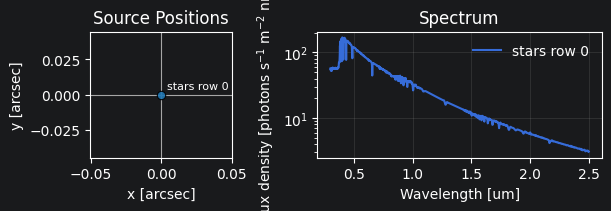

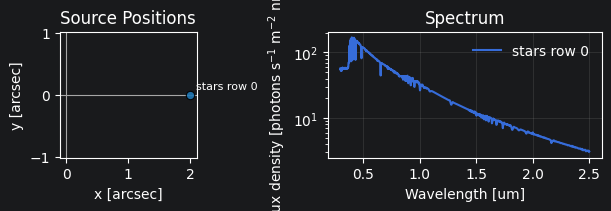

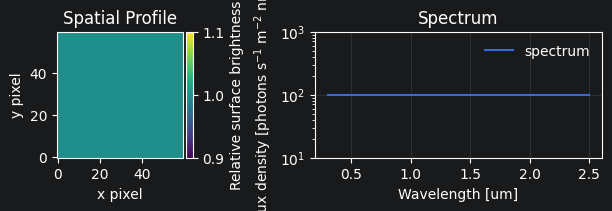

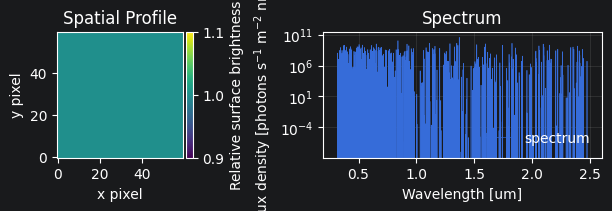

In [12]:
fig, axes = plot_source(star_on_slit_center, individual=True, spectrum_yscale="log")
fig, axes = plot_source(star_on_slit_plus2, individual=True, spectrum_yscale="log")
fig, axes = plot_source(constant_photon_flat, spectrum_yscale="log")
lamp_plot_wave = np.linspace(0.3, 2.5, 12000) * u.um
fig, axes = plot_source(calibration_lamp, wave=lamp_plot_wave, spectrum_yscale="log", spectrum_linewidth=0.45)

## Multi-Star Slit/ADC/PSF Scene

This is the visual geometry check: it shows where table-backed sources land in the slit frame, then convolves the positions with the configured PSF and atmospheric-dispersion/ADC residual model. It is not a detector readout and should not be interpreted as extracted flux.

along_slit_centered


source_index,label,x_arcsec,y_arcsec,in_slit
0,source_0,-2.500000,0.000000,True
1,source_1,2.500000,0.000000,True


across_slit_one_off


source_index,label,x_arcsec,y_arcsec,in_slit
0,source_0,0.000000,0.000000,True
1,source_1,0.000000,0.900000,False


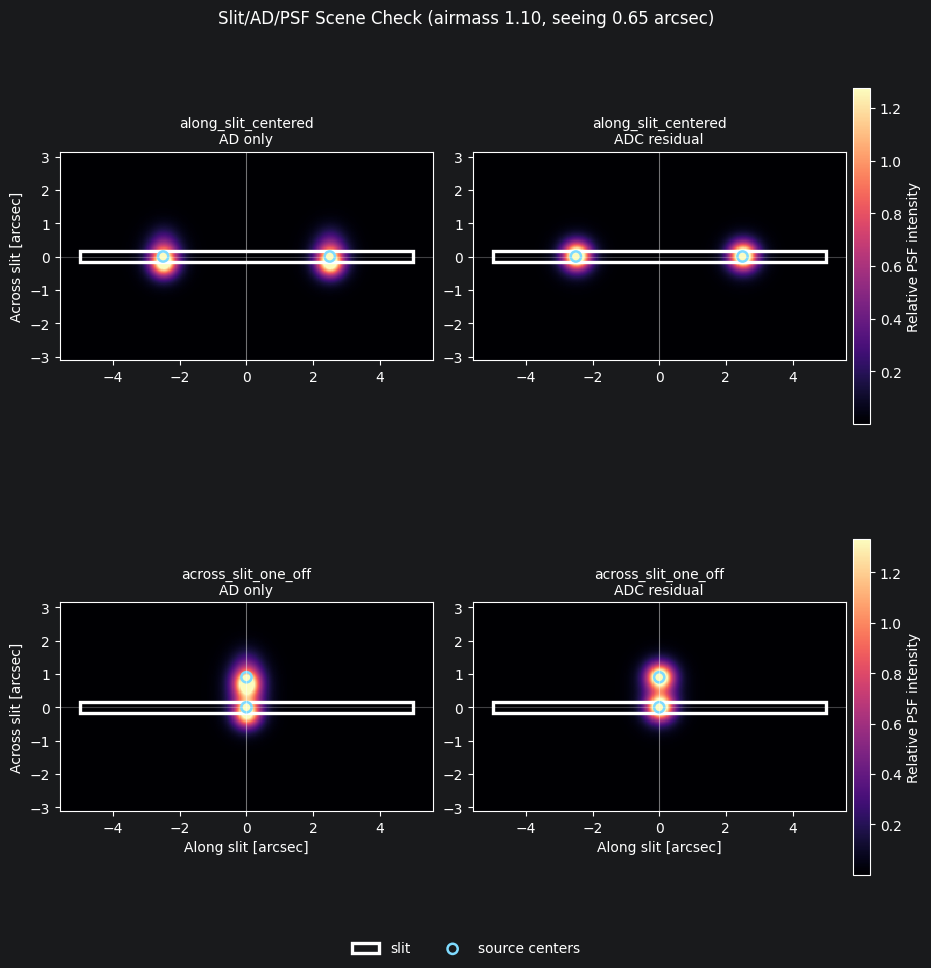

In [13]:
slit_scene_data = build_slit_adc_psf_scene_data(zs, slit_demo_sources, slit_width=cmd_value("!INST.vis_curr_slit")*u.arcsec, slit_length=10*u.arcsec, grid_step=0.035*u.arcsec)
fig, axes = plot_slit_adc_psf_scenes(slit_scene_data)
for name, scenario in slit_scene_data["scenarios"].items():
    print(name)
    display_frame(scenario["status"])

## Background Budget: Sky, Telescope, Instrument, Detector

The goal here is not just to list components but to make them comparable. The emissivity and post-disperser diffuse tables report photon/electron rates in detector-relevant units, while the detailed surface rows remain available for debugging. Telescope mirror emission must appear as a pre-disperser term; if it disappears, the optical accounting is incomplete.

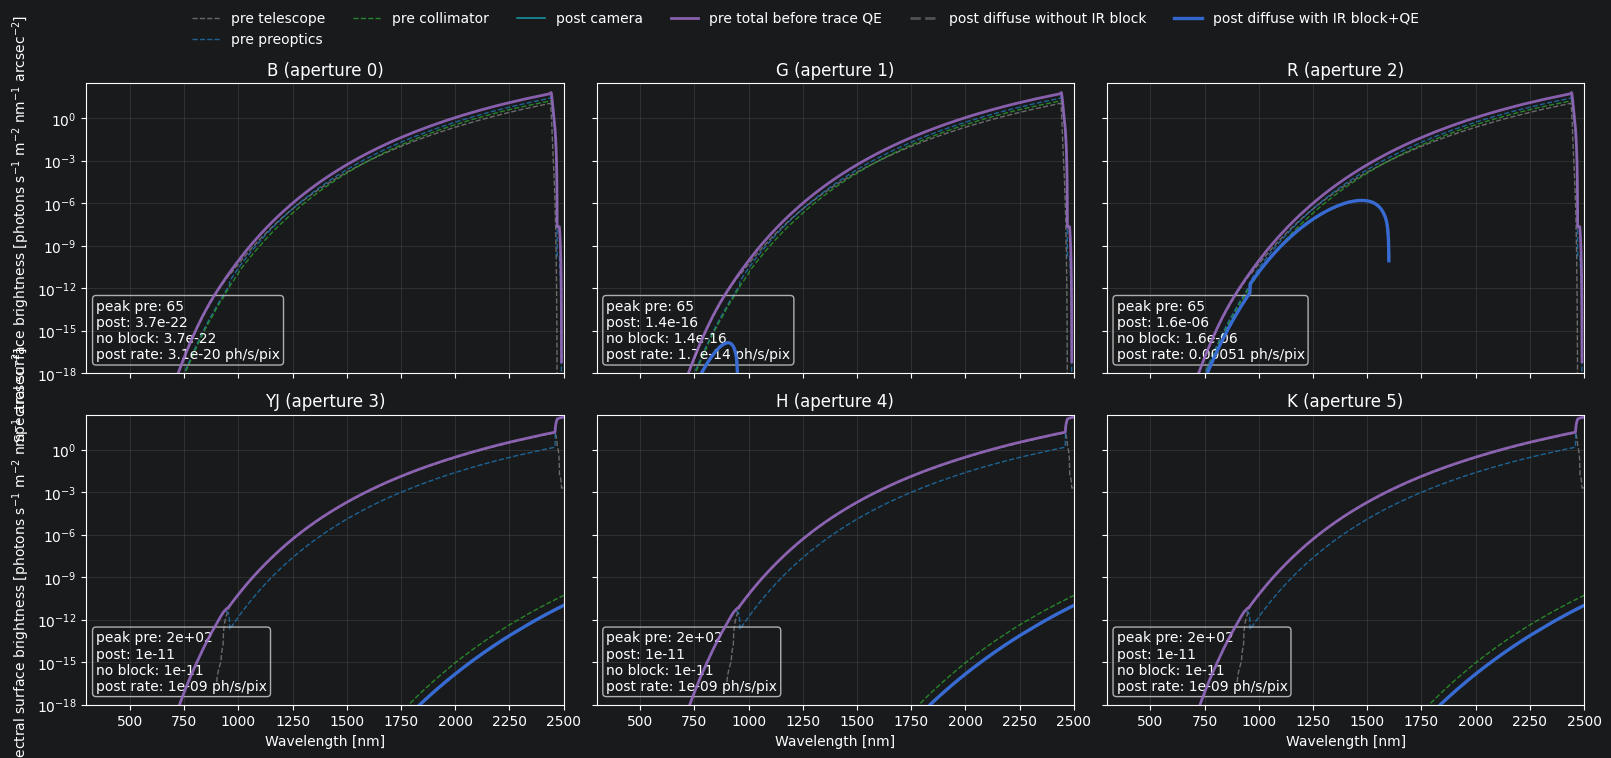

In [14]:
emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)

In [15]:
emissivity_rows = []
for aperture_id, channel in emissivity_data["channels"].items():
    telescope = channel["pre_disperser_terms"].get("telescope", np.zeros_like(channel["pre_disperser_output_equiv"]))
    pre_no_telescope = channel["pre_disperser_output_equiv"] - telescope
    emissivity_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "peak_telescope_thermal_photlam_equiv": np.nanmax(telescope),
        "peak_other_pre_disperser_photlam_equiv": np.nanmax(pre_no_telescope),
        "peak_post_after_qe_photlam_equiv": np.nanmax(channel["post_disperser_after_qe"]),
        "post_diffuse_ph_s_pix": channel["post_disperser_rate_ph_s_pix"],
        "post_diffuse_without_ir_block_ph_s_pix": channel["post_disperser_without_blocking_rate_ph_s_pix"],
        "removed_by_ir_block_ph_s_pix": channel["post_disperser_without_blocking_rate_ph_s_pix"] - channel["post_disperser_rate_ph_s_pix"],
    })
emissivity_summary = Table(rows=emissivity_rows)
display_frame(
    emissivity_summary,
    columns=["channel", "peak_telescope_thermal_photlam_equiv", "peak_other_pre_disperser_photlam_equiv", "peak_post_after_qe_photlam_equiv", "post_diffuse_ph_s_pix", "post_diffuse_without_ir_block_ph_s_pix", "removed_by_ir_block_ph_s_pix"],
    rename={
        "peak_telescope_thermal_photlam_equiv": "peak telescope thermal [ph/s/cm2/A equiv]",
        "peak_other_pre_disperser_photlam_equiv": "peak other pre-disperser [ph/s/cm2/A equiv]",
        "peak_post_after_qe_photlam_equiv": "peak post-disperser after QE [ph/s/cm2/A equiv]",
        "post_diffuse_ph_s_pix": "post diffuse [ph/s/pix]",
        "post_diffuse_without_ir_block_ph_s_pix": "post diffuse no IR block [ph/s/pix]",
        "removed_by_ir_block_ph_s_pix": "removed by IR block [ph/s/pix]",
    },
    formats={
        "peak telescope thermal [ph/s/cm2/A equiv]": "{:.3e}",
        "peak other pre-disperser [ph/s/cm2/A equiv]": "{:.3e}",
        "peak post-disperser after QE [ph/s/cm2/A equiv]": "{:.3e}",
        "post diffuse [ph/s/pix]": "{:.3e}",
        "post diffuse no IR block [ph/s/pix]": "{:.3e}",
        "removed by IR block [ph/s/pix]": "{:.3e}",
    },
)

surface_debug_columns = ["channel", "component", "surface", "group", "emission_phase", "action", "temperature", "emissivity_source", "transmission_source", "peak_after_qe"]
display_frame(
    emissivity_data["details"],
    columns=surface_debug_columns,
    rename={
        "emission_phase": "emission phase",
        "temperature": "temperature [K]",
        "emissivity_source": "emissivity source",
        "transmission_source": "transmission source",
        "peak_after_qe": "peak after QE [ph/s/cm2/A equiv]",
    },
    formats={"temperature [K]": "{:.0f}", "peak after QE [ph/s/cm2/A equiv]": "{:.3e}"},
)


channel,peak telescope thermal [ph/s/cm2/A equiv],peak other pre-disperser [ph/s/cm2/A equiv],peak post-disperser after QE [ph/s/cm2/A equiv],post diffuse [ph/s/pix],post diffuse no IR block [ph/s/pix],removed by IR block [ph/s/pix]
B,1.143e-04,6.069e-04,3.689e-27,3.100e-20,3.100e-20,0.000e+00
G,1.143e-04,6.069e-04,1.403e-21,1.746e-14,1.746e-14,0.000e+00
R,1.143e-04,6.069e-04,1.570e-11,5.067e-04,5.067e-04,0.000e+00
YJ,1.590e-04,2.017e-03,1.040e-16,1.043e-09,1.043e-09,0.000e+00
H,1.590e-04,2.017e-03,1.040e-16,1.043e-09,1.043e-09,0.000e+00
K,1.590e-04,2.017e-03,1.040e-16,1.043e-09,1.043e-09,0.000e+00


channel,component,surface,group,emission phase,action,temperature [K],emissivity source,transmission source,peak after QE [ph/s/cm2/A equiv]
B,telescope_reflection,M1,telescope,pre_disperser,reflection,4,inferred from reflection,inferred from reflection,3.708e-05
B,telescope_reflection,M2,telescope,pre_disperser,reflection,4,inferred from reflection,inferred from reflection,3.809e-05
B,telescope_reflection,M3,telescope,pre_disperser,reflection,4,inferred from reflection,inferred from reflection,3.912e-05
B,channel_optics_selector,VIS_Fold,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,2.651e-05
B,channel_optics_selector,VIS_PreOptFirst,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,4.555e-05
B,channel_optics_selector,VIS_ADC_12,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,5.008e-05
B,channel_optics_selector,VIS_ADC_34,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,5.515e-05
B,channel_optics_selector,VIS_Derotator_AR_1,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,6.207e-05
B,channel_optics_selector,VIS_Derotator_AR_2,preoptics,pre_disperser,transmission,0,inferred from transmission,explicit,7.043e-05
B,channel_optics_selector,VIS_Derotator_Refl_1,preoptics,pre_disperser,reflection,0,inferred from reflection,inferred from reflection,3.005e-05


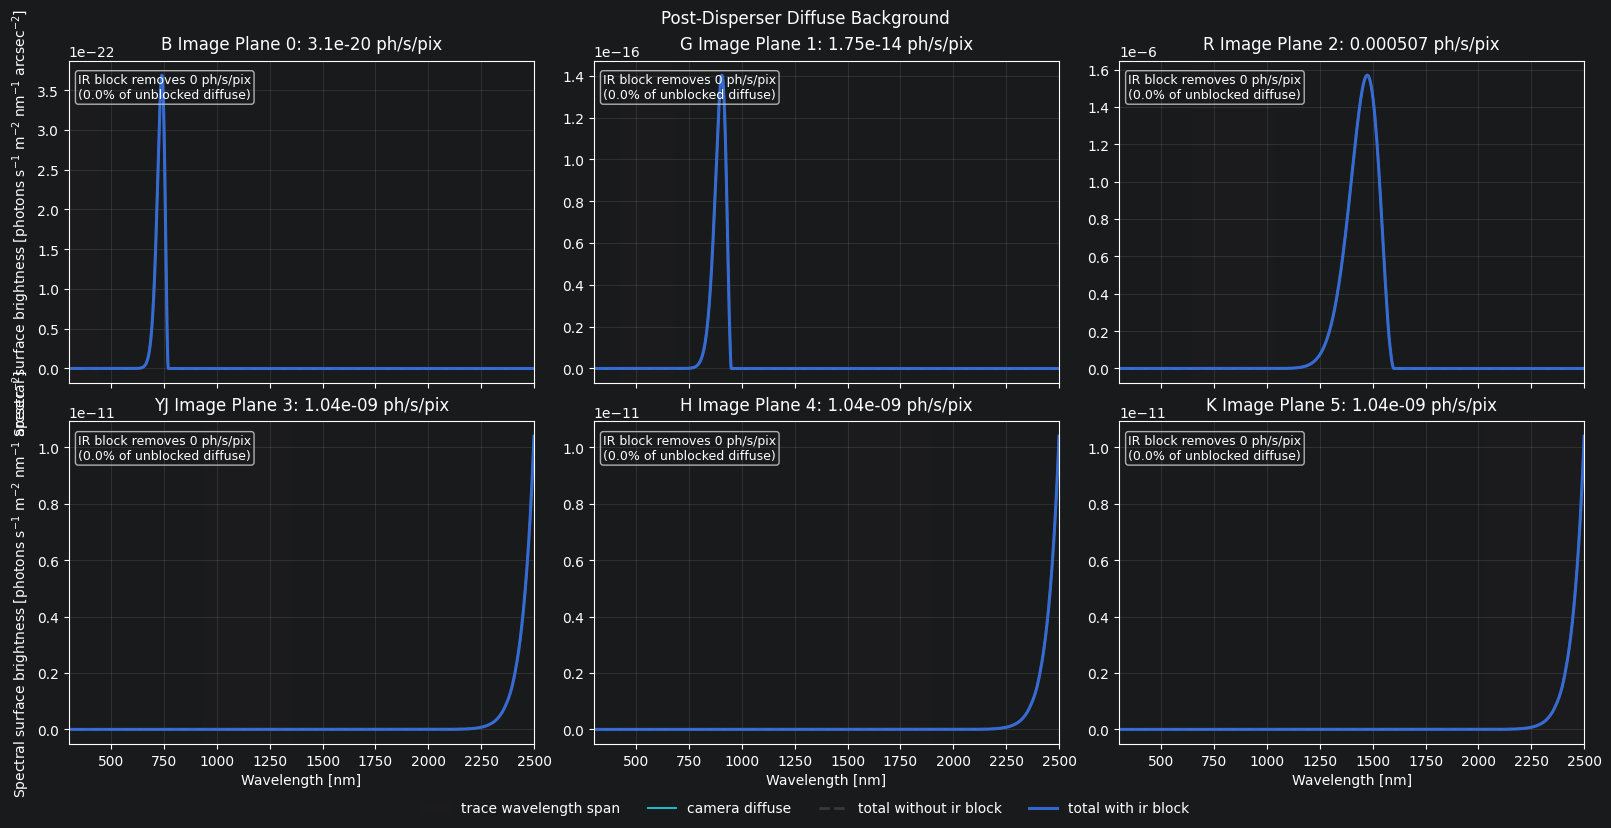

In [16]:
post_diffuse_data = build_post_disperser_diffuse_background_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_post_disperser_diffuse_background_data(post_diffuse_data)
fig, axes = plot_post_disperser_diffuse_background(post_diffuse_data)

if cmd["!INST.include_diffuse_emmisivity"]:
    post_diffuse_consistency = post_disperser_diffuse_effect_consistency_table(zs, post_diffuse_data, qe_selector_name=None, component_metadata=component_metadata)
    validate_post_disperser_diffuse_effect_consistency(post_diffuse_consistency)
    display_frame(post_diffuse_consistency)

In [17]:
qe_accounting = detector_qe_accounting_table(transmission_data, emissivity_data, post_diffuse_data)
display_frame(qe_accounting)

detector_geometry = detector_geometry_table(zs)
display_frame(detector_geometry)
display_frame(detector_selector_matrix(zs))


path,aperture_id,channel,qe_model,trace_mapped_qe,transmission_plot_qe,diffuse_qe,diffuse_position_samples,order_qe_methods,position_axis,position_min,position_max
transmission_trace_mapped,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,4,H,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,5,K,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
emissivity_sanity,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,,nan,None,None


detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
0,0,B,CCD_B,2048,4096,0.015000,1.000000
1,1,G,CCD_G,2048,4096,0.015000,1.000000
2,2,R,CCD_R,2048,4096,0.015000,1.000000
3,3,YJ,APD_YJ,2048,2048,0.015000,1.000000
4,4,H,APD_H,2048,2048,0.015000,1.000000
5,5,K,APD_K,2048,2048,0.015000,1.000000


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,"filename=None, current_slit=0.33"
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,TaperedQuantumEfficiency,filename=None
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=300.0, ndit=1"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=300.0, ndit=1, value=1e-05"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=1, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,"filename=None, current_slit=0.33"
1,G,CCD_G,channel_optics_selector,aperture_id,1,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat


detector_id,image_plane_id,channel,detector,dit_s,ndit,exposure_time_s,post_diffuse_rate_ph_s_pix,post_diffuse_e_pix,dark_current_e_s_pix,dark_current_e_pix,additive_signal_e_pix,bias_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,read_noise_e_rms,diffuse_shot_noise_e_rms,dark_shot_noise_e_rms,total_noise_e_rms
0,0,B,CCD_B,300.000000,1.000000,300.000000,0.000000,0.000000,0.000010,0.003000,0.003000,1040.000000,64000.000000,0.000000,ok,0.100000,0.000000,0.054772,0.114018
1,1,G,CCD_G,300.000000,1.000000,300.000000,0.000000,0.000000,0.000010,0.003000,0.003000,1040.000000,64000.000000,0.000000,ok,0.100000,0.000002,0.054772,0.114018
2,2,R,CCD_R,300.000000,1.000000,300.000000,0.000507,0.151996,0.000010,0.003000,0.154996,1040.000000,64000.000000,0.000002,ok,0.100000,0.389867,0.054772,0.406197
3,3,YJ,APD_YJ,300.000000,1.000000,300.000000,0.000000,0.000000,0.000010,0.003000,0.003000,1040.000000,64000.000000,0.000000,ok,0.500000,0.000559,0.054772,0.502991
4,4,H,APD_H,300.000000,1.000000,300.000000,0.000000,0.000000,0.000010,0.003000,0.003000,1040.000000,64000.000000,0.000000,ok,0.500000,0.000559,0.054772,0.502991
5,5,K,APD_K,300.000000,1.000000,300.000000,0.000000,0.000000,0.000010,0.003000,0.003000,1040.000000,64000.000000,0.000000,ok,0.500000,0.000559,0.054772,0.502991


detector_id,image_plane_id,channel,detector,current_slit_arcsec,wavelength_mid_nm,spectral_resolution_R,resolution_element_nm,pixel_area_arcsec2,post_diffuse_ph_s_pix,post_diffuse_ph_s_arcsec2,extraction_pixels,post_diffuse_ph_s_extraction,post_diffuse_e_extraction,additive_signal_e_pix,full_well_e,signal_fraction_of_full_well,saturation_status,note
0,0,B,CCD_B,0.330000,371.632587,40000.000000,0.009291,0.024199,0.000000,0.000000,4.000000,0.000000,0.000000,0.003000,64000.000000,0.000000,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
1,1,G,CCD_G,0.330000,546.404525,40000.000000,0.013660,0.024199,0.000000,0.000000,4.000000,0.000000,0.000000,0.003000,64000.000000,0.000000,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
2,2,R,CCD_R,0.330000,832.718789,40000.000000,0.020818,0.024199,0.000507,0.020937,4.000000,0.002027,0.607984,0.154996,64000.000000,0.000002,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
3,3,YJ,APD_YJ,0.330000,1141.719963,40000.000000,0.028543,0.024199,0.000000,0.000000,4.000000,0.000000,0.000001,0.003000,64000.000000,0.000000,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
4,4,H,APD_H,0.330000,1678.871994,40000.000000,0.041972,0.024199,0.000000,0.000000,4.000000,0.000000,0.000001,0.003000,64000.000000,0.000000,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."
5,5,K,APD_K,0.330000,2250.606507,40000.000000,0.056265,0.024199,0.000000,0.000000,4.000000,0.000000,0.000001,0.003000,64000.000000,0.000000,ok,"Diffuse rate is integrated image-plane background; resolution_element_nm is an anchor, not a spectral bin for this term."


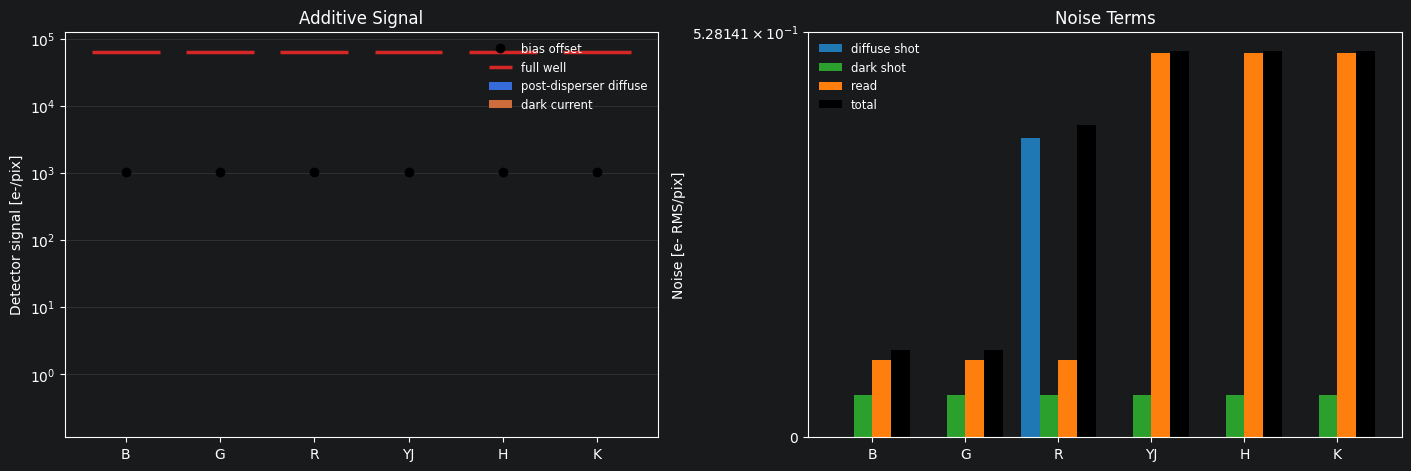

In [18]:
detector_budget = detector_background_budget_table(zs, post_diffuse_data=post_diffuse_data, post_diffuse_consistency=post_diffuse_consistency if  cmd["!INST.include_diffuse_emmisivity"] else None)
fig, axes = plot_detector_background_budget(detector_budget)
display_frame(detector_budget)

science_truth_checks = science_truth_crosscheck_table(zs, post_diffuse_data=post_diffuse_data, detector_budget=detector_budget, extraction_pixels=4.0)
display_frame(science_truth_checks)


## Sky Spectrum Components

This plots the active sky/background spectra in the same run configuration. `atmo_transmission` is multiplicative; with no source and sky emission disabled, it multiplies zero and has no impact on an empty-scene readout. Sky continuum and sky lines are additive backgrounds and are toggled explicitly in the readout scenarios below.

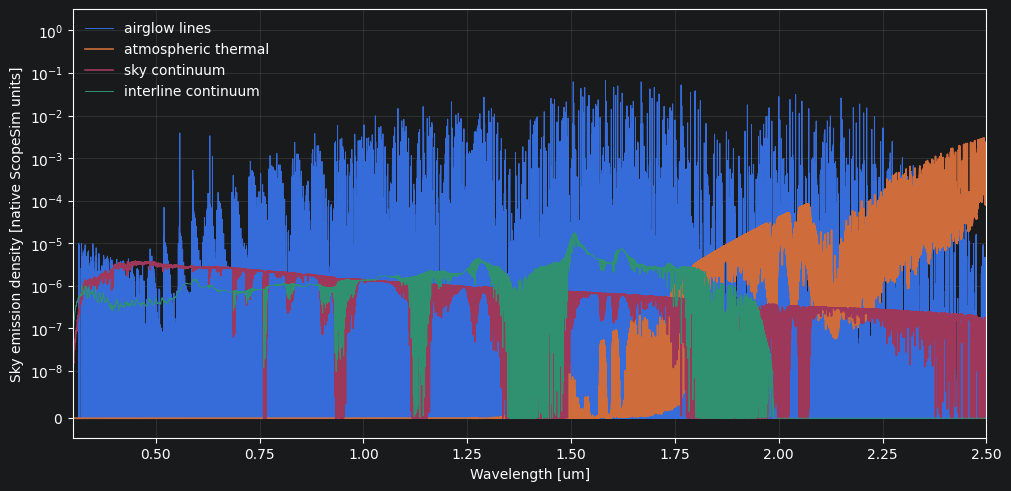

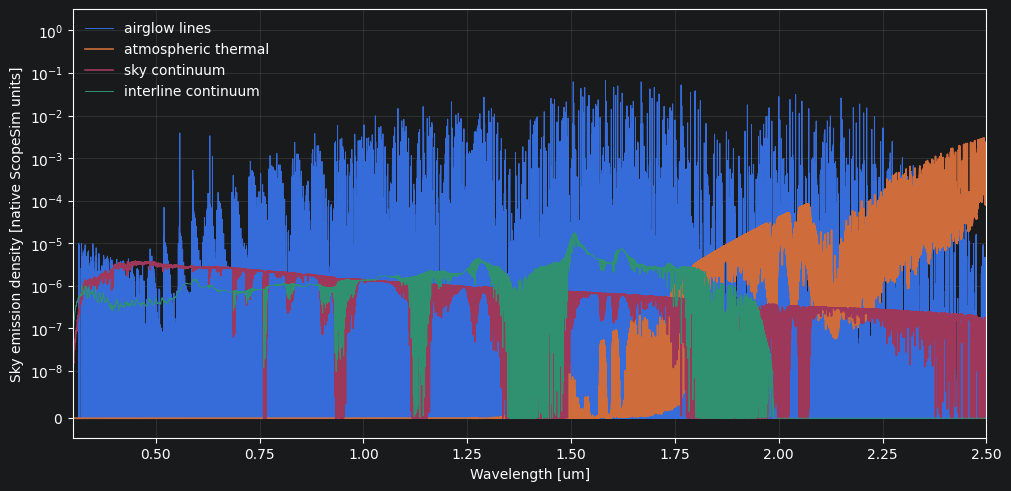

In [19]:
sky_effects = OrderedDict([
    ("airglow lines", ("airglow_and_interline_continuum", "line_TER.emission")),
    ("atmospheric thermal", ("atmo_transmission", "emission")),
    ("sky continuum", ("continuum_emission", "emission")),
    ("interline continuum", ("airglow_and_interline_continuum", "continuum_TER.emission")),
])
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
for label, (effect_name_text, attribute) in sky_effects.items():
    wave_um, values = fetch_effect_spectrum_or_transmission(zs, effect_name_text, attribute)
    ax.plot(wave_um.to_value(u.um), np.asarray(getattr(values, "value", values), dtype=float), lw=0.7 if "line" in label else 1.2, label=label)
ax.set_xlabel("Wavelength [um]")
ax.set_ylabel("Sky emission density [native ScopeSim units]")
ax.set_yscale("symlog", linthresh=1e-8)
ax.set_xlim(0.3, 2.5)
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig

## TIS Back-Of-The-Envelope Anchor

Total integrated scatter from bright sky lines is still a follow-up ScopeSim/IRDB effect. The CDR notebook uses the same physical shape shown here: `TIS = (4 pi sigma / lambda)^2`, then the camera accepts roughly `TIS * Omega_camera / (2 pi)` for a reflective grating scatter hemisphere. This is not added to the readout below; it is the scale that should be promoted into an instrument effect in a separate atomic ScopeSim/IRDB change.

term,expression,status
TIS,(4*pi*sigma/lambda)^2,BoE only here
camera acceptance,TIS * Omega_camera / (2*pi),needs ScopeSim effect
detector distribution,"requires line source, scatter kernel, and detector geometry",follow-up atomic ScopeSim/IRDB change


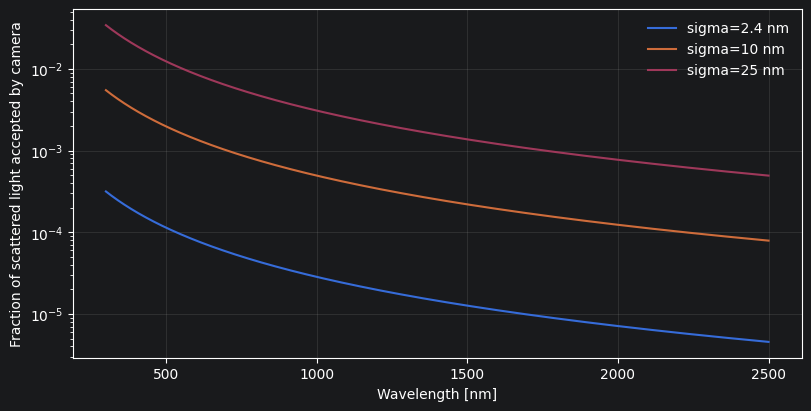

In [20]:
def tis_fraction_into_camera(wave_nm, surface_roughness_rms_nm=2.4, camera_fnum=2.0):
    wave_nm = np.asarray(wave_nm, dtype=float)
    tis = (4*np.pi*surface_roughness_rms_nm/wave_nm)**2
    camera_solid_angle = np.pi/(4*camera_fnum**2)
    return tis * camera_solid_angle/(2*np.pi)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for sigma_nm in (2.4, 10.0, 25.0):
    ax.plot(wave_nm.to_value(u.nm), tis_fraction_into_camera(wave_nm.to_value(u.nm), sigma_nm), label=f"sigma={sigma_nm:g} nm")
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Fraction of scattered light accepted by camera")
ax.set_yscale("log")
ax.grid(alpha=0.2)
ax.legend(frameon=False)

tis_notes = Table(rows=[
    {"term": "TIS", "expression": "(4*pi*sigma/lambda)^2", "status": "BoE only here"},
    {"term": "camera acceptance", "expression": "TIS * Omega_camera / (2*pi)", "status": "needs ScopeSim effect"},
    {"term": "detector distribution", "expression": "requires line source, scatter kernel, and detector geometry", "status": "follow-up atomic ScopeSim/IRDB change"},
])
display_frame(tis_notes)

## Source Photon Scale

This table anchors the source before any detector image is interpreted. It integrates the source over one representative resolution element at each channel midpoint and multiplies by representative order throughput. It is intentionally a back-of-the-envelope scale, not an extracted-spectrum model.

In [21]:
source_photon_checks = source_photon_crosscheck_table(source_to_observe, zs, transmission_data, detector_budget=detector_budget)
display_frame(source_photon_checks)

aperture_id,channel,wavelength_mid_nm,spectral_resolution_R,resolution_element_nm,source_ph_s_resel_at_telescope,representative_order_throughput,source_ph_s_resel_at_detector,exposure_time_s,source_e_resel,note
0,B,371.514303,40000.000000,0.009288,46.963203,0.566925,26.624601,300.000000,7987.380150,"Back-of-envelope source scale at channel midpoint; detector image visibility still depends on trace mapping, slit loss, PSF, extraction aperture, and background."
1,G,546.229246,40000.000000,0.013656,106.503663,0.388557,41.382759,300.000000,12414.827561,"Back-of-envelope source scale at channel midpoint; detector image visibility still depends on trace mapping, slit loss, PSF, extraction aperture, and background."
2,R,832.726545,40000.000000,0.020818,69.288710,0.370551,25.675027,300.000000,7702.508030,"Back-of-envelope source scale at channel midpoint; detector image visibility still depends on trace mapping, slit loss, PSF, extraction aperture, and background."
3,YJ,1141.668334,40000.000000,0.028542,52.481905,0.238782,12.531718,300.000000,3759.515260,"Back-of-envelope source scale at channel midpoint; detector image visibility still depends on trace mapping, slit loss, PSF, extraction aperture, and background."
4,H,1679.015803,40000.000000,0.041975,25.749246,0.391098,10.070470,300.000000,3021.141128,"Back-of-envelope source scale at channel midpoint; detector image visibility still depends on trace mapping, slit loss, PSF, extraction aperture, and background."
5,K,2250.690138,40000.000000,0.056267,17.936441,0.332521,5.964241,300.000000,1789.272218,"Back-of-envelope source scale at channel midpoint; detector image visibility still depends on trace mapping, slit loss, PSF, extraction aperture, and background."


## Readout Scenarios And Background Toggles

These toggles change active effect `include` flags in the already-built optical train, so they do not rebuild the train. That is the useful notebook pattern for asking: source only, sky-line impact, sky-continuum impact, diffuse-emissivity impact. Use `None` for no disabled background. Allowed strings are `sky`, `sky_continuum`, `sky_lines`, and `diffuse_emissivity`.

In [22]:
_BACKGROUND_EFFECT_NAMES = {
    "sky_continuum": ("continuum_emission",),
    "sky_lines": ("airglow_and_interline_continuum",),
    "sky": ("continuum_emission", "airglow_and_interline_continuum"),
    "diffuse_emissivity": ("post_echelle_diffuse_background_selector",),
}

@contextmanager
def disable_background(name_or_names):
    if name_or_names is None:
        yield
        return
    requested = [name_or_names] if isinstance(name_or_names, str) else list(name_or_names)
    effect_names = []
    for name in requested:
        if name not in _BACKGROUND_EFFECT_NAMES:
            raise ValueError(f"Unknown background selector {name!r}; choose from {sorted(_BACKGROUND_EFFECT_NAMES)}")
        effect_names.extend(_BACKGROUND_EFFECT_NAMES[name])
    effects = []
    for effect_name_text in dict.fromkeys(effect_names):
        effect = get_effect(zs, effect_name_text, active_only=False)
        effects.append((effect, getattr(effect, "include", True)))
    try:
        for effect, _include in effects:
            effect.include = False
        yield
    finally:
        for effect, include in effects:
            effect.include = include

def observe_readout(source=None, disabled_background=None):
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    with disable_background(disabled_background), disable_scopesim_progress_bars(hide_scopesim_progress):
        if source is None:
            zs.observe()
        else:
            zs.observe(source)
        hdul = zs.readout()
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    return hdul

def save_hdul(fig, hdul, titles=('B', 'G', 'R', 'YJ', 'H', 'K')):
    fig.savefig(output_dir / "zspec_echellogram.png", dpi=300)
    for title, channel_hdul in zip(titles, hdul):
        channel_hdul.writeto(output_dir / f"zspec_{title}.fits", overwrite=True)

In [23]:
readout_titles = ["B", "G", "R", "YJ", "H", "K"]
readout_scale_groups = [["B", "G", "R"], ["YJ", "H", "K"]]
readouts = OrderedDict()

In [24]:
readouts["source_full_background"] = observe_readout(source_to_observe, None)

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

astar.scopesim.utils - WARNING: Obstime is not after sunset!


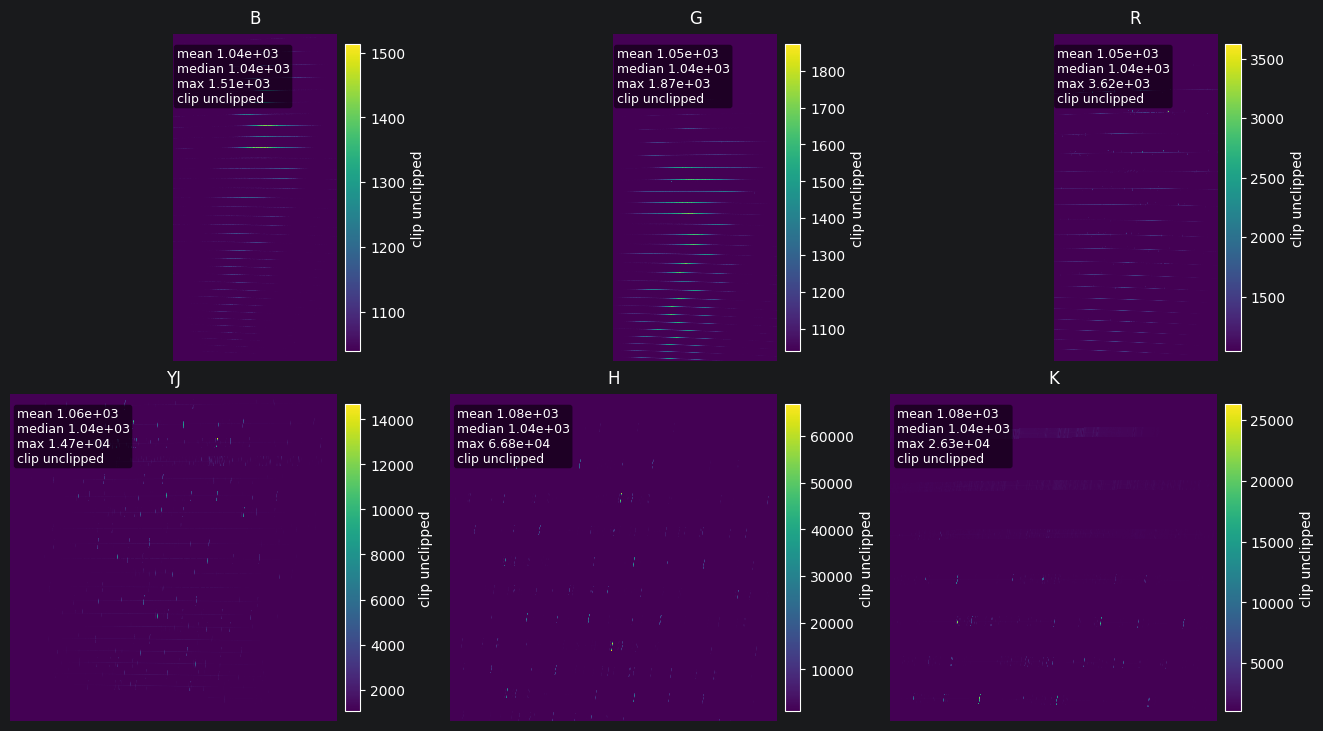

In [25]:
fig, axes = plot_readout_overview(readouts["source_full_background"], titles=readout_titles, clip=None, shared_scale=False, annotate_stats=True, cmap="viridis", zero_floor=False)#, vmax=(1300))

In [26]:
save_hdul(fig, readouts["source_full_background"], titles=readout_titles)

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()

py.warnings - WARNING: /Users/jibailey/src/ScopeSim/scopesim/effects/spectral_trace_list.py:207: DeprecationWarning: The fov_grid method is deprecated and will be removed in a future release.
  vol = spt.fov_grid()



readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,15637265.000000,15923428.000000,-286163.000000,473.000000,-6.000000,473.000000,1261698
1,G,4096x2048,55717171.000000,56383127.000000,-665956.000000,708.000000,-64.000000,708.000000,1792104
2,R,4096x2048,52297271.000000,53464041.000000,-1166770.000000,620.000000,-166.000000,620.000000,1864055
3,YJ,2048x2048,28468887.000000,30476527.000000,-2007640.000000,573.000000,-366.000000,573.000000,1675019
4,H,2048x2048,10940749.000000,13471862.000000,-2531113.000000,995.000000,-936.000000,995.000000,1127426
5,K,2048x2048,6036404.000000,10458400.000000,-4421996.000000,641.000000,-503.000000,641.000000,844428


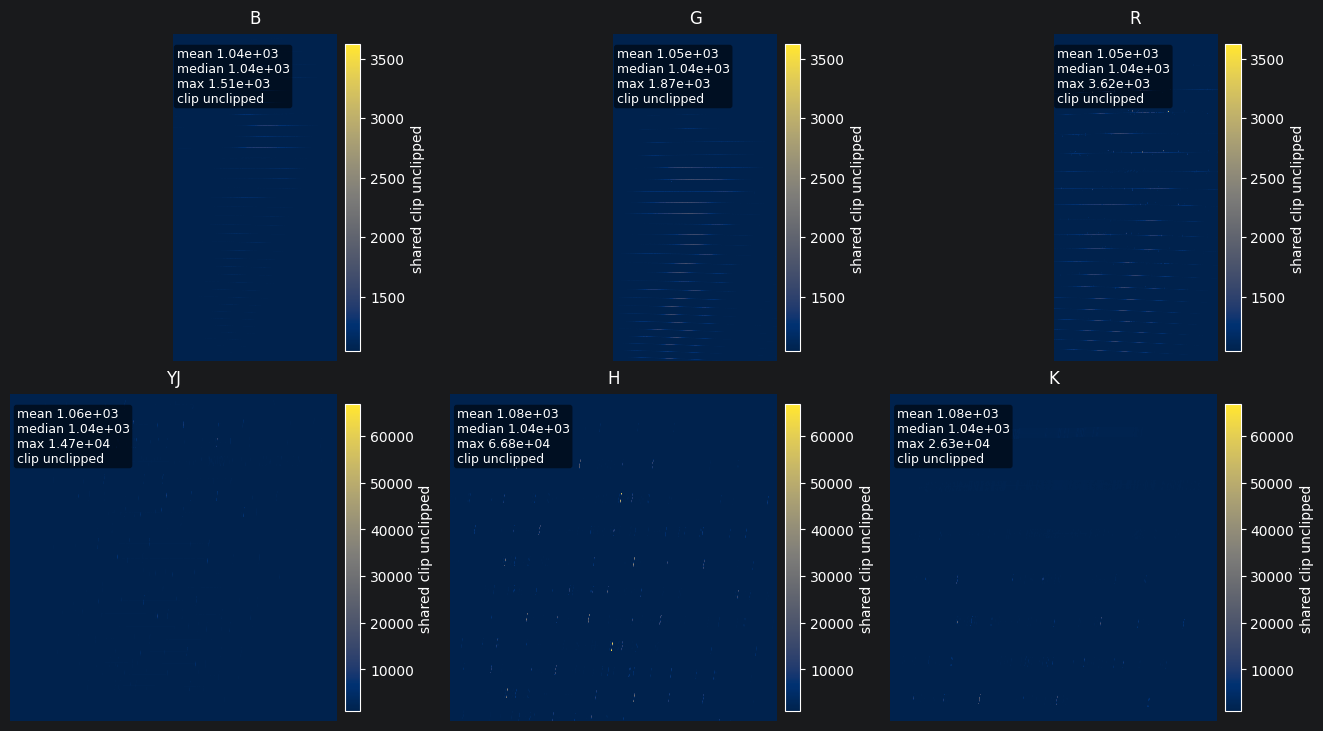

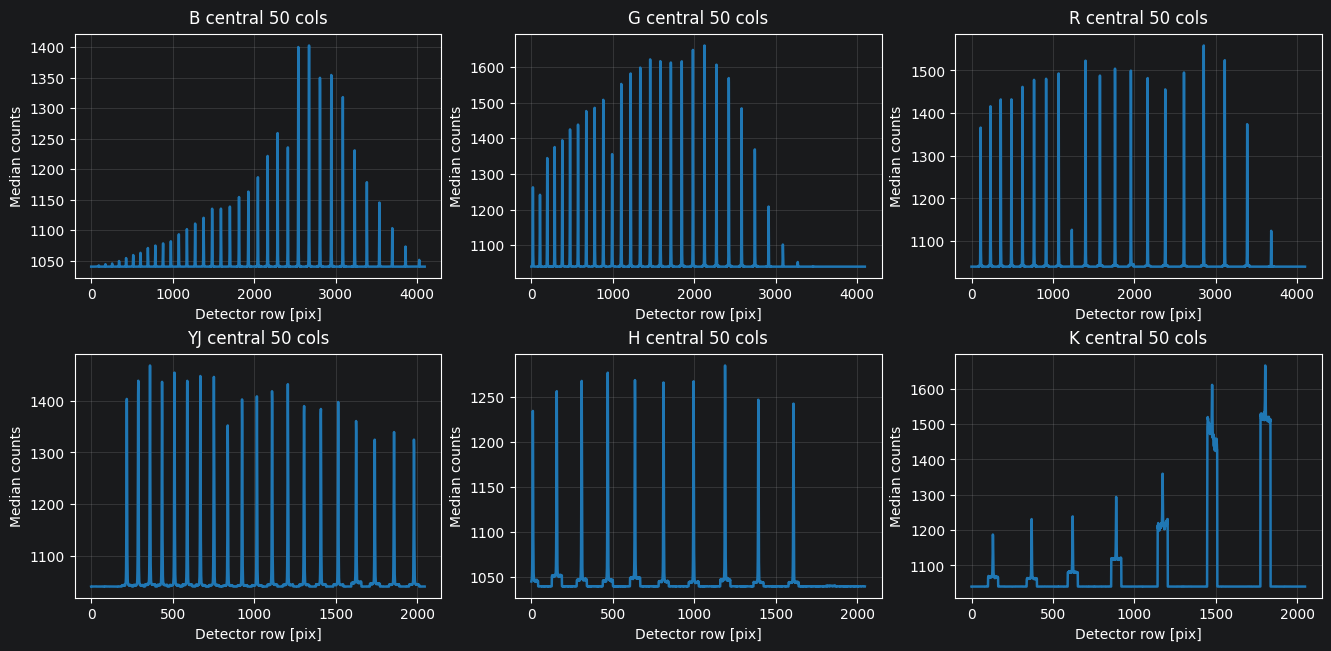

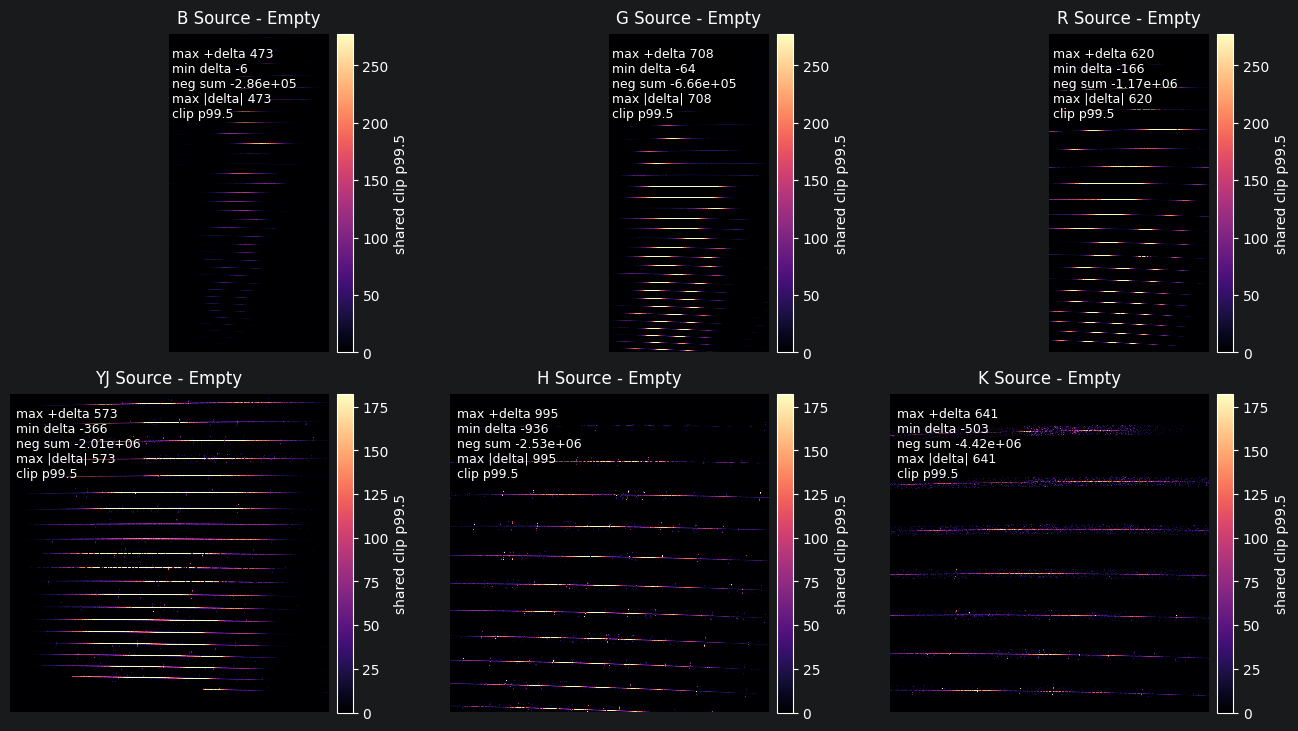

In [27]:
readouts["empty_full_background"] = observe_readout(None, None)
readouts["source_no_sky_lines"] = observe_readout(source_to_observe, ["sky_lines"])
readouts["source_no_sky_continuum"] = observe_readout(source_to_observe, ["sky_continuum"])
readouts["source_no_diffuse_emissivity"] = observe_readout(source_to_observe, ["diffuse_emissivity"])

fig, axes = plot_readout_overview(readouts["source_full_background"], titles=readout_titles, clip=None, shared_scale=readout_scale_groups, annotate_stats=True, zero_floor=False)
fig, axes = plot_readout_cross_dispersion_cut(readouts["source_full_background"], titles=readout_titles)
source_minus_empty = readout_delta_summary_table(readouts["source_full_background"], readouts["empty_full_background"], titles=readout_titles)
display_frame(source_minus_empty)
fig, axes = plot_readout_delta_overview(readouts["source_full_background"], readouts["empty_full_background"], titles=readout_titles, clip=0.995, shared_scale=readout_scale_groups, title_suffix=" Source - Empty")


sky line contribution


readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,148041.000000,1849542.000000,-1701501.000000,87.000000,-93.000000,93.000000,1237155
1,G,4096x2048,395266.000000,3788990.000000,-3393724.000000,395.000000,-142.000000,395.000000,1755778
2,R,4096x2048,6443551.000000,9345394.000000,-2901843.000000,2181.000000,-131.000000,2181.000000,1813160
3,YJ,2048x2048,51939449.000000,53429023.000000,-1489574.000000,13392.000000,-105.000000,13392.000000,1646885
4,H,2048x2048,172770537.000000,173290436.000000,-519899.000000,65806.000000,-74.000000,65806.000000,1164930
5,K,2048x2048,46631101.000000,51002731.000000,-4371630.000000,25249.000000,-166.000000,25249.000000,851619


sky continuum contribution


readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,392002.000000,1934663.000000,-1542661.000000,84.000000,-81.000000,84.000000,1174659
1,G,4096x2048,1566373.000000,4316673.000000,-2750300.000000,120.000000,-125.000000,125.000000,1671928
2,R,4096x2048,1848506.000000,4766180.000000,-2917674.000000,140.000000,-148.000000,148.000000,1788425
3,YJ,2048x2048,1042094.000000,4357853.000000,-3315759.000000,422.000000,-459.000000,459.000000,1635366
4,H,2048x2048,508698.000000,3720277.000000,-3211579.000000,1044.000000,-1011.000000,1044.000000,1114845
5,K,2048x2048,241908.000000,5349695.000000,-5107787.000000,605.000000,-540.000000,605.000000,850186


diffuse emissivity contribution


readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,G,4096x2048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
2,R,4096x2048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
3,YJ,2048x2048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
4,H,2048x2048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
5,K,2048x2048,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0


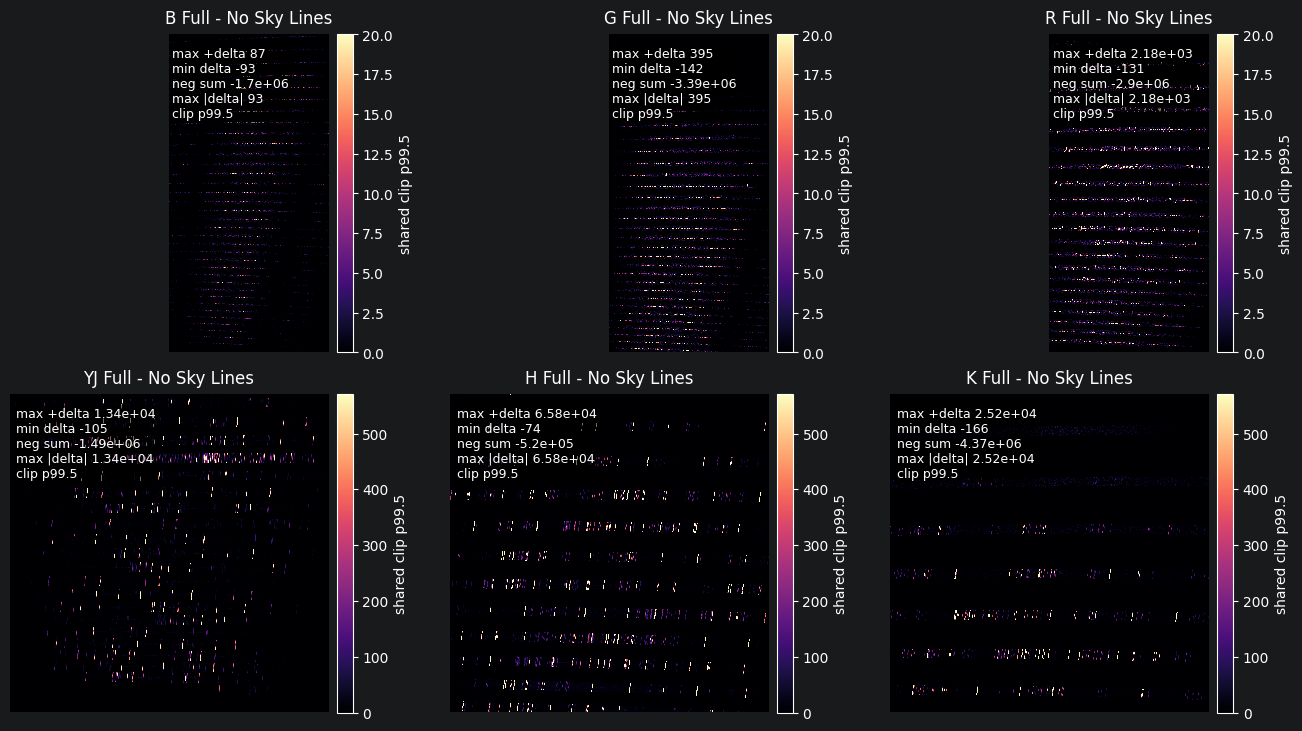

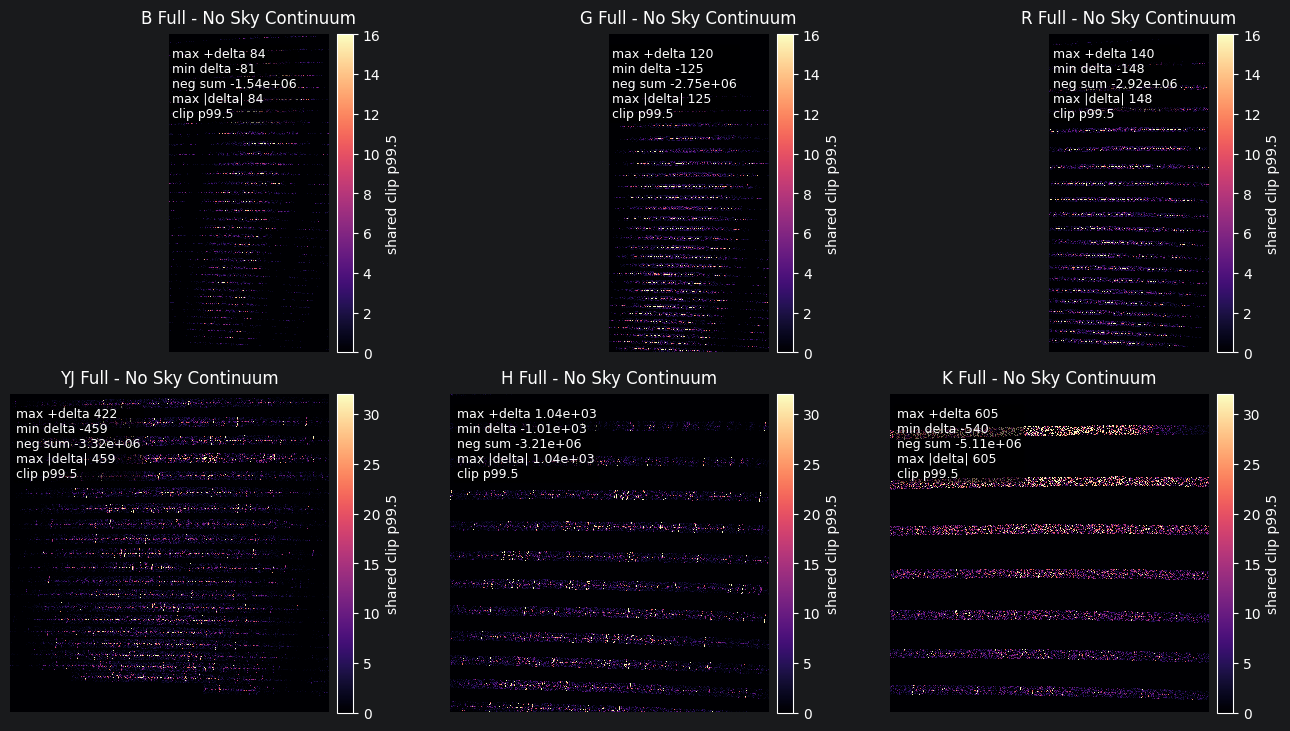

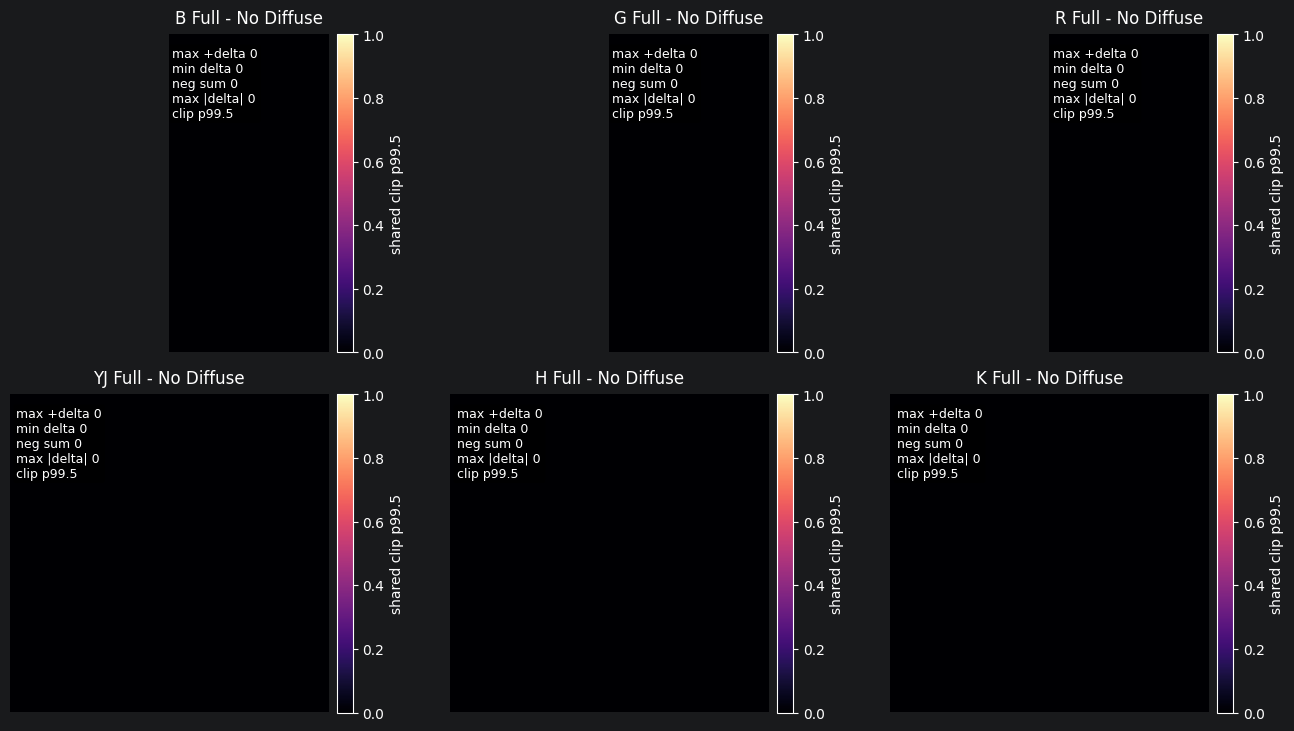

In [28]:
scenario_deltas = OrderedDict([
    ("sky line contribution", (readouts["source_full_background"], readouts["source_no_sky_lines"], " Full - No Sky Lines")),
    ("sky continuum contribution", (readouts["source_full_background"], readouts["source_no_sky_continuum"], " Full - No Sky Continuum")),
    ("diffuse emissivity contribution", (readouts["source_full_background"], readouts["source_no_diffuse_emissivity"], " Full - No Diffuse")),
])
for label, (signal, reference, suffix) in scenario_deltas.items():
    print(label)
    display_frame(readout_delta_summary_table(signal, reference, titles=readout_titles))
    fig, axes = plot_readout_delta_overview(signal, reference, titles=readout_titles, clip=0.995, shared_scale=readout_scale_groups, title_suffix=suffix)

## Per-Pixel And Resolution-Element S/N Diagnostics

The first image is a detector-pixel diagnostic: `source_full_background - empty_full_background`, with Poisson noise from the positive source term, nonnegative empty-background term, and detector read noise. The display scale is shared across channels so YJ, H, and K can be compared directly.

The second image is an approximate FWHM-resolution-element S/N view. It multiplies the same per-pixel S/N by `sqrt(N_pix)`, where `N_pix` is derived from the trace-resolution diagnostic above: spectral FWHM pixels from the loaded trace metadata/dispersion, and spatial FWHM pixels from the active PSF/seeing and image-plane pixel scale. This is not an aperture sum and not an optimal extraction; the source-minus-empty image remains the product to send to extraction code.

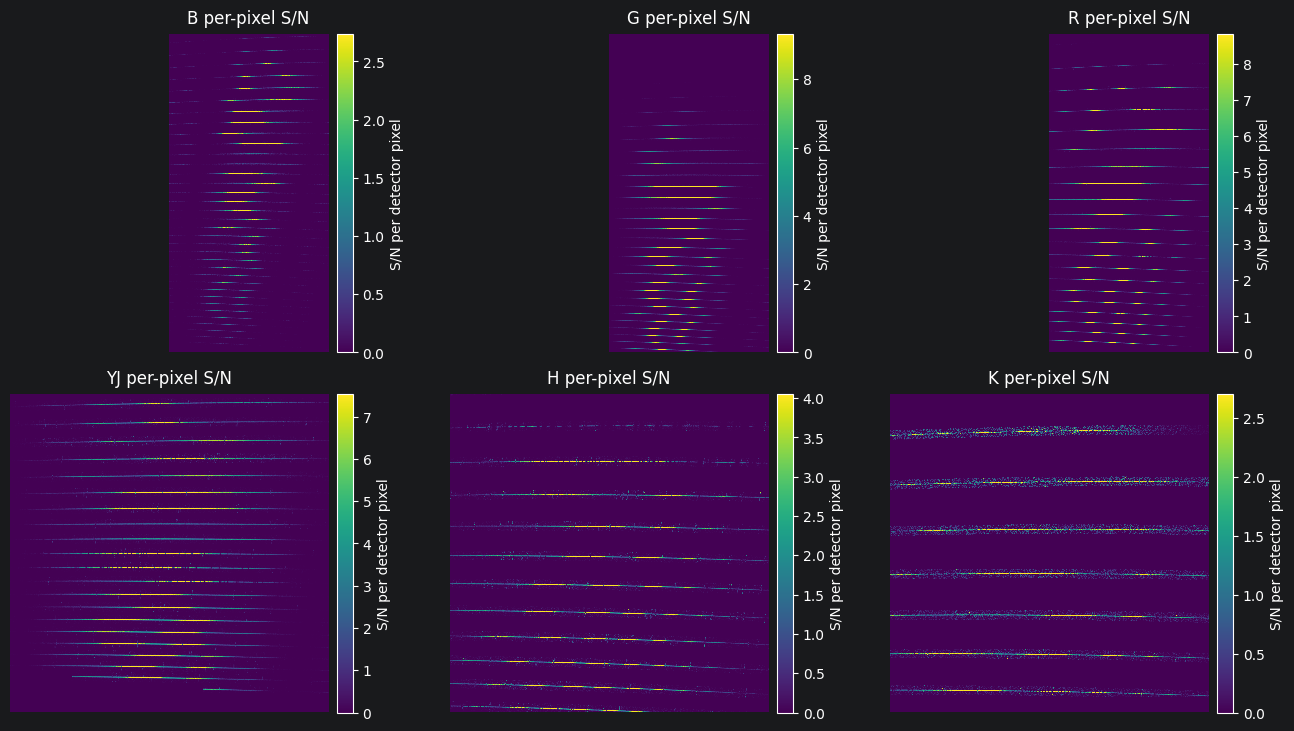

channel,active slit [arcsec],R median,dispersion [nm/pix],spectral width [pix],seeing [arcsec],spatial width [pix],resel footprint [pix],S/N scale sqrt(pix)
B,0.33,14782,0.0054,3.4-5.4,0.73,4.5-4.9,16.7-24.6,4.59
G,0.33,14726,0.0078,3.5-5.3,0.68,4.2-4.6,15.8-22.5,4.42
R,0.33,14770,0.0119,3.5-5.3,0.63,3.8-4.2,14.6-20.9,4.24
YJ,0.33,14657,0.0170,3.6-5.2,0.59,3.6-3.9,13.6-19.6,4.09
H,0.33,14640,0.0253,3.6-5.2,0.54,3.4-3.6,12.7-17.8,3.94
K,0.33,14694,0.0339,3.6-5.2,0.51,3.2-3.3,12.0-16.8,3.82


channel,median positive pixel S/N,resel footprint [pix],S/N scale sqrt(pix),median resel S/N,positive S/N pixels,median spectral width [pix],median spatial width [pix]
B,0.06,21.0,4.59,0.28,1015050,4.5,4.7
G,0.09,19.6,4.42,0.41,1333622,4.5,4.4
R,0.09,18.0,4.24,0.39,1277801,4.5,4.0
YJ,0.09,16.8,4.09,0.38,1093172,4.5,3.8
H,0.09,15.5,3.94,0.37,682393,4.5,3.5
K,0.30,14.6,3.82,1.15,478376,4.5,3.3


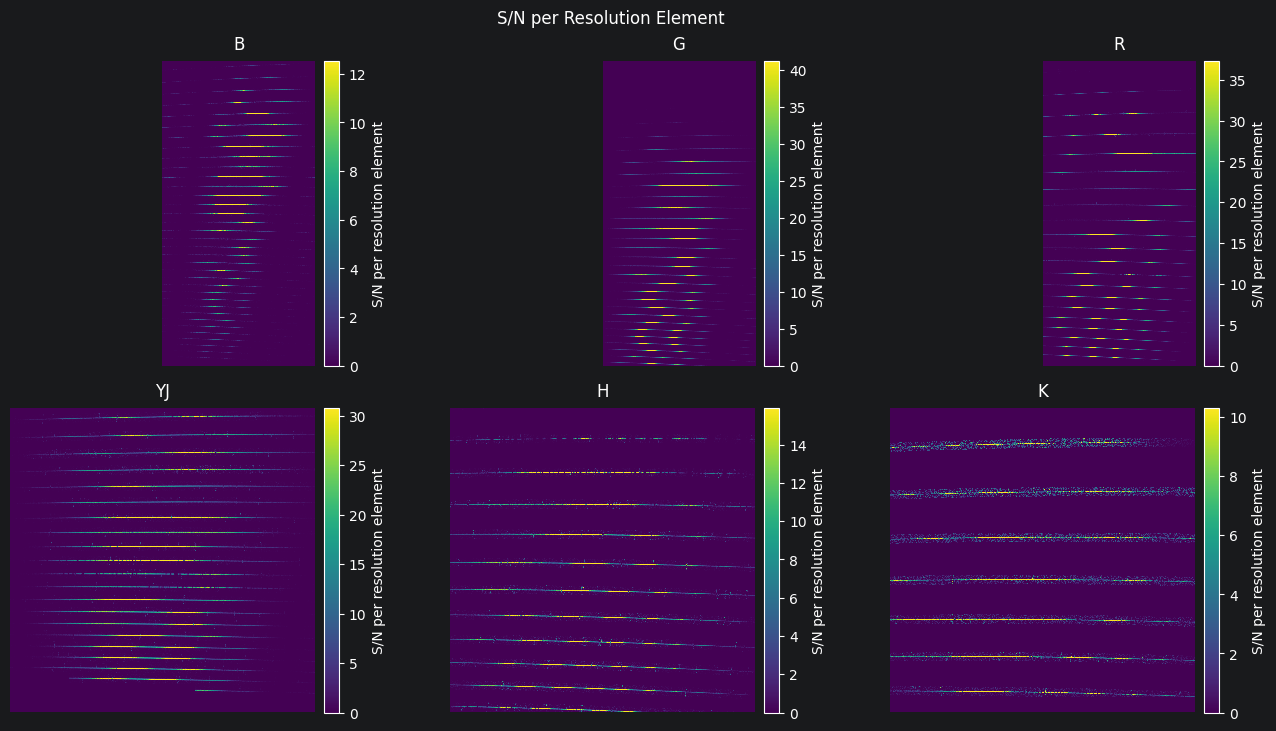

In [29]:
def readout_image(channel_hdul):
    image_hdu = channel_hdul if hasattr(channel_hdul, "data") else channel_hdul[1]
    return np.asarray(image_hdu.data, dtype=float)

read_noise_by_channel = {str(row["channel"]): float(row["read_noise_e_rms"]) for row in detector_budget}
signal_images = []
snr_images = []
for title, source_hdu, empty_hdu in zip(readout_titles, readouts["source_full_background"], readouts["empty_full_background"], strict=True):
    signal = readout_image(source_hdu) - readout_image(empty_hdu)
    signal_pos = np.clip(signal, 0, None)
    background = np.clip(readout_image(empty_hdu), 0, None)
    read_noise = read_noise_by_channel[title]
    variance = signal_pos + background + read_noise**2
    snr = np.divide(signal_pos, np.sqrt(variance), out=np.zeros_like(signal_pos), where=variance > 0)
    signal_images.append(signal)
    snr_images.append(snr)

fig, axes = plot_detector_image_grid(
    snr_images,
    titles=[f"{title} per-pixel S/N" for title in readout_titles],
    clip=0.995,
    shared_scale=False,
    colorbar_mode="per-panel",
    colorbar_label="S/N per detector pixel",
    cmap="viridis",
    zero_floor=True,
)
display(fig)
plt.close(fig)

resolution_rows = []
resolution_display_rows = []
for row in trace_resolution_summary:
    channel = str(row["channel"])
    spectral_min = float(row["typical_spectral_element_width_min_pix"])
    spectral_median = float(row["typical_spectral_element_width_median_pix"])
    spectral_max = float(row["typical_spectral_element_width_max_pix"])
    spatial_min = float(row["spatial_fwhm_min_pix"])
    spatial_median = float(row["spatial_fwhm_median_pix"])
    spatial_max = float(row["spatial_fwhm_max_pix"])
    resel_min = float(row["resel_footprint_min_pix"])
    resel_median = float(row["resel_footprint_median_pix"])
    resel_max = float(row["resel_footprint_max_pix"])
    snr_scale = float(np.sqrt(resel_median))
    resolution_rows.append({
        "channel": channel,
        "current_slit_arcsec": cmd_value("!INST.vis_curr_slit") if channel in {"B", "G", "R"} else cmd_value("!INST.nir_curr_slit"),
        "trace_R_median": float(row["trace_R_median"]),
        "dispersion_median_nm_pix": float(row["dispersion_median_nm_pix"]),
        "spectral_fwhm_pix": spectral_median,
        "spectral_fwhm_min_pix": spectral_min,
        "spectral_fwhm_max_pix": spectral_max,
        "psf_fwhm_median_arcsec": float(row["seeing_fwhm_median_arcsec"]),
        "pixel_scale_arcsec_pix": float(row["pixel_scale_arcsec_pix"]),
        "spatial_fwhm_pix": spatial_median,
        "spatial_fwhm_min_pix": spatial_min,
        "spatial_fwhm_max_pix": spatial_max,
        "resel_pixels_fwhm": resel_median,
        "resel_pixels_min_fwhm": resel_min,
        "resel_pixels_max_fwhm": resel_max,
        "snr_resel_scale": snr_scale,
    })
    resolution_display_rows.append({
        "channel": channel,
        "active slit [arcsec]": cmd_value("!INST.vis_curr_slit") if channel in {"B", "G", "R"} else cmd_value("!INST.nir_curr_slit"),
        "R median": float(row["trace_R_median"]),
        "dispersion [nm/pix]": float(row["dispersion_median_nm_pix"]),
        "spectral width [pix]": compact_range(spectral_min, spectral_max, 1),
        "seeing [arcsec]": float(row["seeing_fwhm_median_arcsec"]),
        "spatial width [pix]": compact_range(spatial_min, spatial_max, 1),
        "resel footprint [pix]": compact_range(resel_min, resel_max, 1),
        "S/N scale sqrt(pix)": snr_scale,
    })
resolution_footprint = Table(rows=resolution_rows)
display_frame(
    resolution_display_rows,
    formats={
        "active slit [arcsec]": "{:.2f}",
        "R median": "{:.0f}",
        "dispersion [nm/pix]": "{:.4f}",
        "seeing [arcsec]": "{:.2f}",
        "S/N scale sqrt(pix)": "{:.2f}",
    },
)

resel_snr_summary = resolution_element_snr_summary_table(snr_images, resolution_footprint, titles=readout_titles)
display_frame(
    resel_snr_summary,
    rename={
        "median_positive_pixel_snr": "median positive pixel S/N",
        "resel_pixels_fwhm": "resel footprint [pix]",
        "snr_resel_scale": "S/N scale sqrt(pix)",
        "median_resel_snr": "median resel S/N",
        "positive_snr_pixels": "positive S/N pixels",
        "spectral_fwhm_pix": "median spectral width [pix]",
        "spatial_fwhm_pix": "median spatial width [pix]",
    },
    formats={
        "median positive pixel S/N": "{:.2f}",
        "resel footprint [pix]": "{:.1f}",
        "S/N scale sqrt(pix)": "{:.2f}",
        "median resel S/N": "{:.2f}",
        "median spectral width [pix]": "{:.1f}",
        "median spatial width [pix]": "{:.1f}",
    },
)

snr_scale_by_channel = {str(row["channel"]): float(row["snr_resel_scale"]) for row in resolution_footprint}
resel_snr_images = [snr * snr_scale_by_channel[title] for title, snr in zip(readout_titles, snr_images, strict=True)]
fig, axes = plot_detector_image_grid(
    resel_snr_images,
    titles=readout_titles,
    clip=0.995,
    shared_scale=False,
    colorbar_mode="per-panel",
    colorbar_label="S/N per resolution element",
    cmap="viridis",
    zero_floor=True,
)
fig.suptitle("S/N per Resolution Element")
display(fig)
plt.close(fig)


## What To Report

For a presentation or release note, the key tables are the run card, throughput summary, slit-loss-at-current-slit summary, emissivity summary, detector budget, source photon crosscheck, source-minus-empty delta summary, and the scenario-delta summaries. The plots should answer whether the traces are present, whether sky lines and diffuse backgrounds move the expected pixels, whether telescope/instrument emissivity rates are in the right ballpark, and whether any strong negative deltas appear where only added signal was expected.